# Étude complète d’un matériau cristallin
Notebook structuré selon les consignes du projet.

Remplacer `MATERIAL_NAME` par le matériau attribué.

## 1. Téléchargement de la structure cristalline

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pymatgen as mg

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter

#import pour l'affichage des opérations de symétrie
from jupyter_jsmol.pymatgen import quick_view
from jupyter_jsmol.pymatgen import JsmolView
from pymatgen.io.cif import CifWriter
import plotly.graph_objects as go
from IPython.display import display





#import pymatviz as pv
# Exemple avec pymatgen (Materials Project)
#from mp_api.client import MPRester
from pymatgen.ext.matproj import MPRester  #j'ai mis celui l'autre import ne marche sur mon vscode 
from mp_api.client import MPRester



API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"  #id du LiC dans material project 

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(material_id)

    structure.to(fmt="cif", filename="LiC.cif")

structure






Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Structure Summary
Lattice
    abc : 3.591529777348829 4.011704109915074 4.011704492667927
 angles : 73.52458272493287 63.408171496645096 63.40816766642372
 volume : 45.96833740475323
      A : np.float64(3.20947838) np.float64(0.0) np.float64(1.61193507)
      B : np.float64(1.4266634900000001) np.float64(3.56532885) np.float64(1.16053063)
      C : np.float64(-0.0052797) np.float64(-0.023513299999999) np.float64(4.01163211)
    pbc : True True True
PeriodicSite: Li (3.492, 2.618, 5.05) [0.7607, 0.7393, 0.7393]
PeriodicSite: Li (1.139, 0.9233, 1.734) [0.2393, 0.2607, 0.2607]
PeriodicSite: C (1.24, 3.098, 1.532) [0.0, 0.8697, 0.1303]
PeriodicSite: C (0.1812, 0.444, 3.64) [-0.0, 0.1303, 0.8697]

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Nombres d'atomes dans la maille : 8


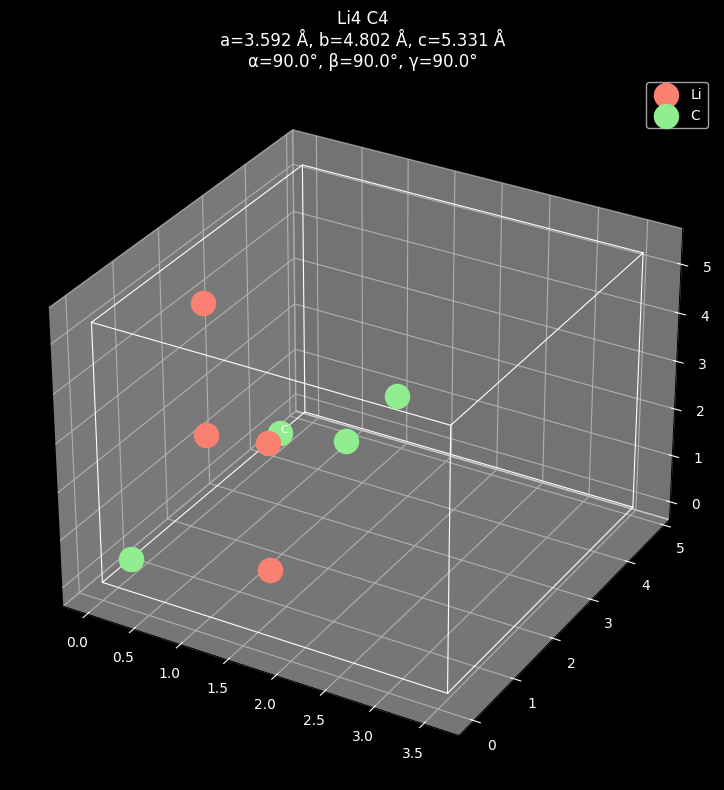

In [2]:

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(material_id,conventional_unit_cell=True)

print(f"Nombres d'atomes dans la maille : {len(structure.sites)}")
couleurs = {"Li": "salmon", "C": "lightgreen"}

fig = plt.figure(figsize=(8, 8), facecolor="black")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("black")

# Tracer les atomes
for site in structure.sites:
    x, y, z = site.coords
    elem = site.species_string
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "white"),
               s=300,
               label=elem)
    ax.text(x, y, z, elem, color="white", fontsize=8)

# Tracer les arêtes de la maille
from itertools import combinations


lattice = structure.lattice.matrix
origin = np.array([0, 0, 0])
vecs = [lattice[0], lattice[1], lattice[2]]

# 12 arêtes de la maille
edges = [
    (origin, vecs[0]),
    (origin, vecs[1]),
    (origin, vecs[2]),
    (vecs[0], vecs[0]+vecs[1]),
    (vecs[0], vecs[0]+vecs[2]),
    (vecs[1], vecs[1]+vecs[0]),
    (vecs[1], vecs[1]+vecs[2]),
    (vecs[2], vecs[2]+vecs[0]),
    (vecs[2], vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]

for start, end in edges:
    ax.plot(*zip(start, end), color="white", linewidth=0.8)

# Infos maille
lattice_params = structure.lattice
ax.set_title(
    f"{structure.formula}\n"
    f"a={lattice_params.a:.3f} Å, b={lattice_params.b:.3f} Å, c={lattice_params.c:.3f} Å\n"
    f"α={lattice_params.alpha:.1f}°, β={lattice_params.beta:.1f}°, γ={lattice_params.gamma:.1f}°",
    color="white"
)

# Légende sans doublons
handles, labels_legend = ax.get_legend_handles_labels()
unique = dict(zip(labels_legend, handles))
ax.legend(unique.values(), unique.keys(), facecolor="black", labelcolor="white")

ax.tick_params(colors="white")
plt.tight_layout()
plt.show()


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


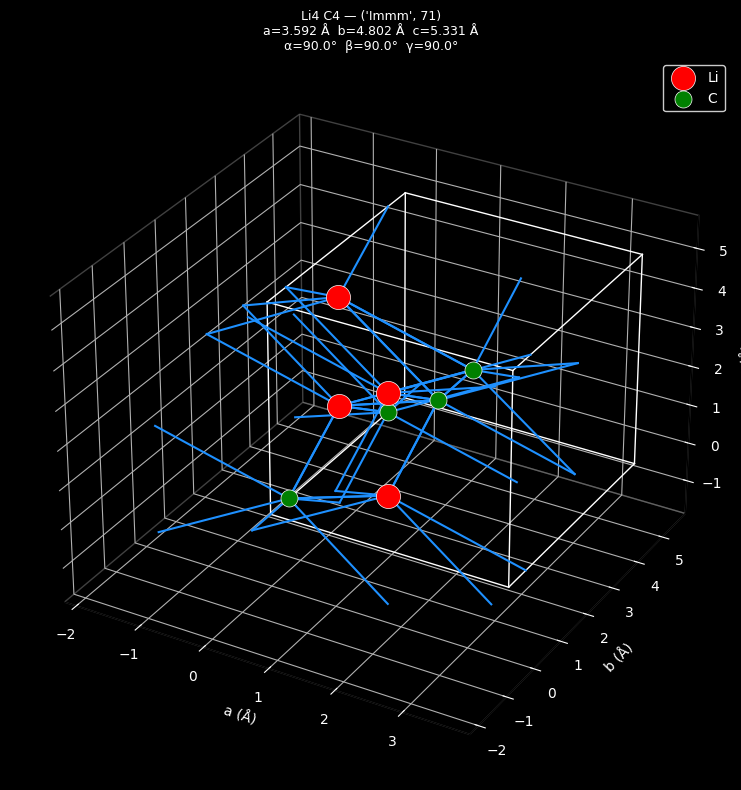

In [ ]:
from mp_api.client import MPRester
from pymatgen.analysis.local_env import CrystalNN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id,
        conventional_unit_cell=True
    )

# Couleurs et tailles par élément
couleurs = {"Li": "red", "C": "green"}
tailles  = {"Li": 300,   "C": 150}

fig = plt.figure(figsize=(10, 8), facecolor="black")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("black")

# ── 1. Liaisons ────────────────────────────────────────────────────────────
cnn = CrystalNN()

for i, site in enumerate(structure.sites):
    try:
        neighbors = cnn.get_nn_info(structure, i)
        for neighbor in neighbors:
            site_j = neighbor["site"]
            xs = [site.coords[0], site_j.coords[0]]
            ys = [site.coords[1], site_j.coords[1]]
            zs = [site.coords[2], site_j.coords[2]]
            ax.plot(xs, ys, zs, color="dodgerblue", linewidth=1.5, zorder=1)
    except:
        pass

# ── 2. Atomes ──────────────────────────────────────────────────────────────
for site in structure.sites:
    elem = site.species_string
    x, y, z = site.coords
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "white"),
               s=tailles.get(elem, 150),
               zorder=2,
               edgecolors="white",
               linewidths=0.5,
               label=elem)

# ── 3. Arêtes de la maille ─────────────────────────────────────────────────
lattice = structure.lattice.matrix
vecs = [lattice[0], lattice[1], lattice[2]]
origin = np.array([0, 0, 0])

edges = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]

for start, end in edges:
    ax.plot(*zip(start, end), color="white", linewidth=1, zorder=0)

# ── 4. Légende sans doublons ───────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(),
          facecolor="black", labelcolor="white",
          edgecolor="white")

# ── 5. Infos maille ────────────────────────────────────────────────────────
lp = structure.lattice
ax.set_title(
    f"{structure.formula} — {structure.get_space_group_info()}\n"
    f"a={lp.a:.3f} Å  b={lp.b:.3f} Å  c={lp.c:.3f} Å\n"
    f"α={lp.alpha:.1f}°  β={lp.beta:.1f}°  γ={lp.gamma:.1f}°",
    color="white", fontsize=9
)

ax.set_xlabel("a (Å)", color="white")
ax.set_ylabel("b (Å)", color="white")
ax.set_zlabel("c (Å)", color="white")
ax.tick_params(colors="white")

# Fond des panneaux 3D en noir
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("gray")
ax.yaxis.pane.set_edgecolor("gray")
ax.zaxis.pane.set_edgecolor("gray")

plt.tight_layout()
plt.savefig("LiC_structure.png", dpi=150, facecolor="black")
plt.show()

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Opération : Rot:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]
tau
[0. 0. 0.]
Atome     : Li
Avant     : [0.     0.5    0.2393]
Après     : [ 0.     -0.5     0.2393]
Après %1  : [0.     0.5    0.2393]


c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


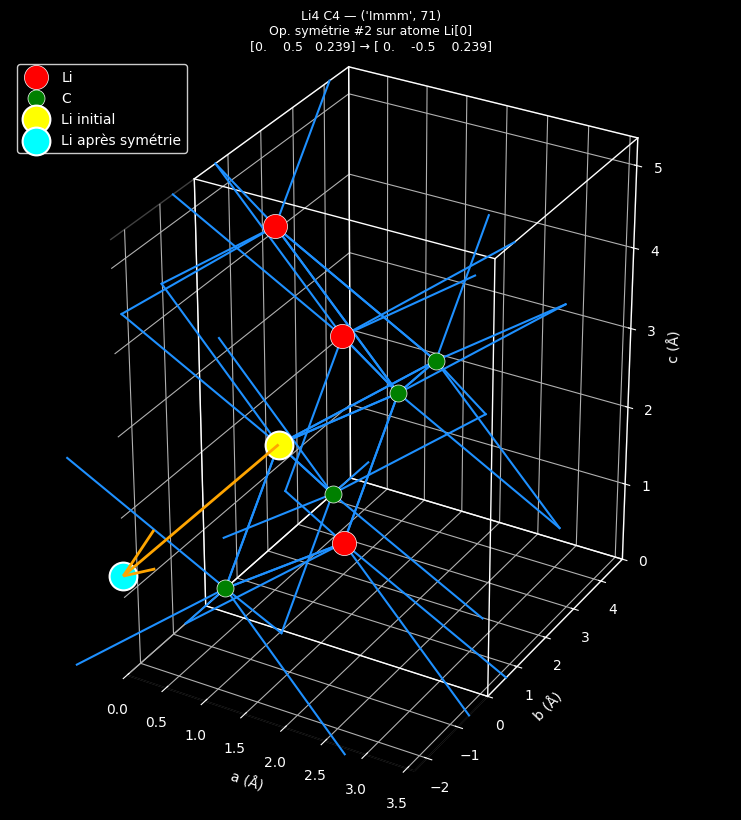

In [11]:
from mp_api.client import MPRester
from pymatgen.core.operations import SymmOp
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

# Récupérer les opérations de symétrie
sga = SpacegroupAnalyzer(structure)
symmops = sga.get_symmetry_operations()

# Choisir un atome et une opération de symétrie
i_atom   = 0  # index de l'atome Li
i_symmop = 2  # index de l'opération (pas l'identité)

symmop    = symmops[i_symmop]
pos_init  = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Opération : {symmop}")
print(f"Atome     : {structure.sites[i_atom].species_string}")
print(f"Avant     : {np.round(pos_init, 4)}")
print(f"Après     : {np.round(pos_final, 4)}")
print(f"Après %1  : {np.round(pos_final % 1, 4)}")

# ── Visualisation ──────────────────────────────────────────────────────────
couleurs = {"Li": "red", "C": "green"}
tailles  = {"Li": 300,   "C": 150}

fig = plt.figure(figsize=(10, 8), facecolor="black")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("black")

# ── 1. Liaisons ────────────────────────────────────────────────────────────
cnn = CrystalNN()
for i, site in enumerate(structure.sites):
    try:
        for neighbor in cnn.get_nn_info(structure, i):
            sj = neighbor["site"]
            ax.plot([site.coords[0], sj.coords[0]],
                    [site.coords[1], sj.coords[1]],
                    [site.coords[2], sj.coords[2]],
                    color="dodgerblue", linewidth=1.5, zorder=1)
    except:
        pass

# ── 2. Tous les atomes (structure inchangée) ───────────────────────────────
for i, site in enumerate(structure.sites):
    elem = site.species_string
    x, y, z = site.coords
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "white"),
               s=tailles.get(elem, 150),
               zorder=2,
               edgecolors="white",
               linewidths=0.5,
               label=elem)

# ── 3. Montrer le mapping de l'atome choisi ────────────────────────────────
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

ax.scatter(*coords_init, color="yellow", s=400,
           zorder=5, edgecolors="white", linewidths=1.5,
           label="Li initial")

ax.scatter(*coords_final, color="cyan", s=400,
           zorder=5, edgecolors="white", linewidths=1.5,
           label="Li après symétrie")

ax.quiver(*coords_init,
          *(coords_final - coords_init),
          color="orange", linewidth=2, arrow_length_ratio=0.2,
          zorder=6)

# ── 4. Arêtes de la maille ─────────────────────────────────────────────────
lattice = structure.lattice.matrix
vecs    = [lattice[0], lattice[1], lattice[2]]
origin  = np.array([0, 0, 0])
edges   = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end), color="white", linewidth=1, zorder=0)

# ── 5. ✅ Corriger les proportions des axes ────────────────────────────────
lp = structure.lattice

# Ratio réel a, b, c
ax.set_box_aspect([lp.a, lp.b, lp.c])

# Limites basées sur les vrais coins cartésiens de la maille
all_corners = np.array([
    i*vecs[0] + j*vecs[1] + k*vecs[2]
    for i in range(2)
    for j in range(2)
    for k in range(2)
])

# Étendre les limites pour inclure pos_final si hors maille
all_points = np.vstack([all_corners, coords_init, coords_final])
ax.set_xlim(all_points[:, 0].min(), all_points[:, 0].max())
ax.set_ylim(all_points[:, 1].min(), all_points[:, 1].max())
ax.set_zlim(all_points[:, 2].min(), all_points[:, 2].max())

# ── 6. Légende et titre ────────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(),
          facecolor="black", labelcolor="white", edgecolor="white")

ax.set_title(
    f"{structure.formula} — {structure.get_space_group_info()}\n"
    f"Op. symétrie #{i_symmop} sur atome "
    f"{structure.sites[i_atom].species_string}[{i_atom}]\n"
    f"{np.round(pos_init, 3)} → {np.round(pos_final, 3)}",
    color="white", fontsize=9
)
ax.set_xlabel("a (Å)", color="white")
ax.set_ylabel("b (Å)", color="white")
ax.set_zlabel("c (Å)", color="white")
ax.tick_params(colors="white")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("gray")
ax.yaxis.pane.set_edgecolor("gray")
ax.zaxis.pane.set_edgecolor("gray")

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=150, facecolor="black")
plt.show()

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Atome  : Li
Avant  : [0.     0.5    0.2393]
Après  : [ 0.     -0.5     0.2393]


c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


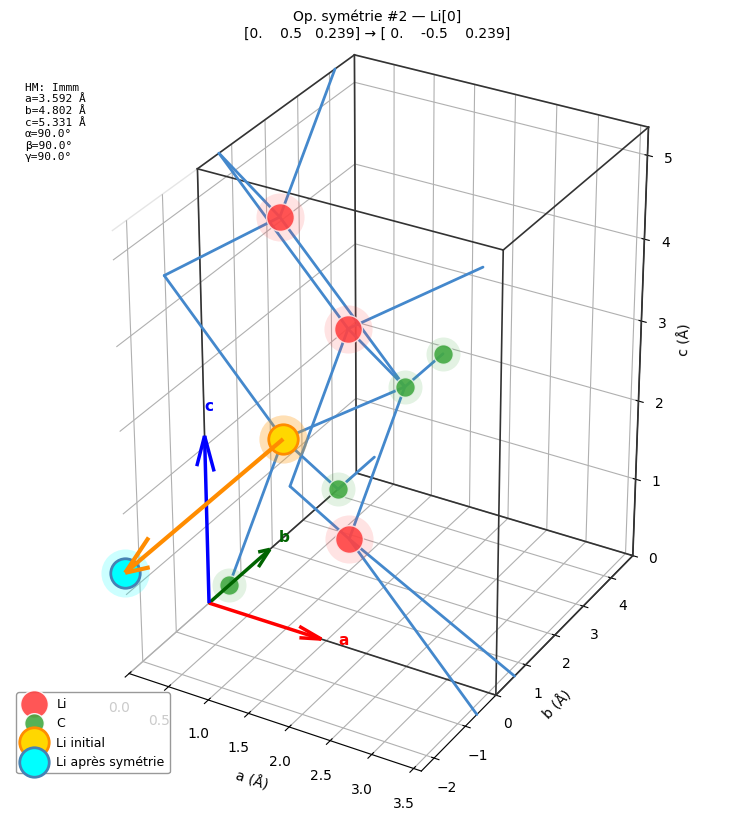

In [12]:
from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

sga      = SpacegroupAnalyzer(structure)
symmops  = sga.get_symmetry_operations()

i_atom   = 0
i_symmop = 2

symmop    = symmops[i_symmop]
pos_init  = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Atome  : {structure.sites[i_atom].species_string}")
print(f"Avant  : {np.round(pos_init, 4)}")
print(f"Après  : {np.round(pos_final, 4)}")

# ── Couleurs et tailles ────────────────────────────────────────────────────
couleurs = {"Li": "#FF4444", "C": "#44AA44"}
tailles  = {"Li": 400,       "C": 200}

# ── Figure fond BLANC ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8), facecolor="white")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")

# ── 1. Liaisons (seulement premier voisin, plus lisible) ───────────────────
cnn = CrystalNN()
deja_traces = set()

for i, site in enumerate(structure.sites):
    try:
        for neighbor in cnn.get_nn_info(structure, i):
            j   = neighbor["site_index"]
            sj  = neighbor["site"]
            key = tuple(sorted([i, j]))
            if key not in deja_traces:
                deja_traces.add(key)
                ax.plot([site.coords[0], sj.coords[0]],
                        [site.coords[1], sj.coords[1]],
                        [site.coords[2], sj.coords[2]],
                        color="#4488CC", linewidth=2, zorder=1,
                        solid_capstyle="round")
    except:
        pass

# ── 2. Atomes (transparents comme JSmol) ──────────────────────────────────
for i, site in enumerate(structure.sites):
    elem = site.species_string
    x, y, z = site.coords
    # Sphère principale
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 200),
               zorder=2,
               edgecolors="white",
               linewidths=1,
               label=elem,
               alpha=0.9)
    # ✅ Halo transparent (comme JSmol)
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 200) * 3,
               zorder=1,
               alpha=0.15,
               linewidths=0)

# ── 3. Atome initial (jaune) et final (cyan) ──────────────────────────────
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

# Halo atome initial
ax.scatter(*coords_init, color="gold", s=1200,
           zorder=4, alpha=0.2, linewidths=0)
ax.scatter(*coords_init, color="gold", s=450,
           zorder=5, edgecolors="darkorange",
           linewidths=2, label="Li initial")

# Halo atome final
ax.scatter(*coords_final, color="cyan", s=1200,
           zorder=4, alpha=0.2, linewidths=0)
ax.scatter(*coords_final, color="cyan", s=450,
           zorder=5, edgecolors="steelblue",
           linewidths=2, label="Li après symétrie")

# ── 4. Flèche orange épaisse (comme JSmol) ────────────────────────────────
deplacement = coords_final - coords_init
ax.quiver(*coords_init,
          *deplacement,
          color="darkorange", linewidth=3,
          arrow_length_ratio=0.15,
          zorder=6)

# ── 5. Arêtes de la maille en gris foncé ──────────────────────────────────
lattice = structure.lattice.matrix
vecs    = [lattice[0], lattice[1], lattice[2]]
origin  = np.array([0, 0, 0])
edges   = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end), color="#333333", linewidth=1.2, zorder=0)

# ── 6. Axes cristallographiques colorés (comme JSmol) ─────────────────────
scale = 0.4  # longueur des axes
axes_colors = {"a": "red", "b": "darkgreen", "c": "blue"}
for vec, (label, color) in zip(vecs, axes_colors.items()):
    direction = vec / np.linalg.norm(vec) * scale * np.linalg.norm(vec)
    ax.quiver(*origin, *direction,
              color=color, linewidth=2.5,
              arrow_length_ratio=0.2, zorder=7)
    ax.text(*(origin + direction * 1.15),
            label, color=color, fontsize=11, fontweight="bold")

# ── 7. Proportions et limites ──────────────────────────────────────────────
lp = structure.lattice
ax.set_box_aspect([lp.a, lp.b, lp.c])

all_corners = np.array([
    i*vecs[0] + j*vecs[1] + k*vecs[2]
    for i in range(2) for j in range(2) for k in range(2)
])
all_points = np.vstack([all_corners, coords_init, coords_final])
ax.set_xlim(all_points[:, 0].min(), all_points[:, 0].max())
ax.set_ylim(all_points[:, 1].min(), all_points[:, 1].max())
ax.set_zlim(all_points[:, 2].min(), all_points[:, 2].max())

# ── 8. Infos maille (coin supérieur gauche comme JSmol) ───────────────────
info = (f"HM: {structure.get_space_group_info()[0]}\n"
        f"a={lp.a:.3f} Å\nb={lp.b:.3f} Å\nc={lp.c:.3f} Å\n"
        f"α={lp.alpha:.1f}°\nβ={lp.beta:.1f}°\nγ={lp.gamma:.1f}°")
ax.text2D(0.02, 0.95, info, transform=ax.transAxes,
          fontsize=8, verticalalignment="top",
          fontfamily="monospace", color="black")

# ── 9. Légende et titre ───────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(),
          facecolor="white", edgecolor="gray", fontsize=9)

ax.set_title(
    f"Op. symétrie #{i_symmop} — "
    f"{structure.sites[i_atom].species_string}[{i_atom}]\n"
    f"{np.round(pos_init,3)} → {np.round(pos_final,3)}",
    fontsize=10, color="black"
)
ax.set_xlabel("a (Å)"); ax.set_ylabel("b (Å)"); ax.set_zlabel("c (Å)")
ax.tick_params(colors="black")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("#CCCCCC")
ax.yaxis.pane.set_edgecolor("#CCCCCC")
ax.zaxis.pane.set_edgecolor("#CCCCCC")
ax.grid(True, color="#EEEEEE", linewidth=0.5)

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=150, facecolor="white")
plt.show()

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Atome  : Li
Avant  : [0.     0.5    0.2393]
Après  : [ 0.     -0.5     0.2393]


c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


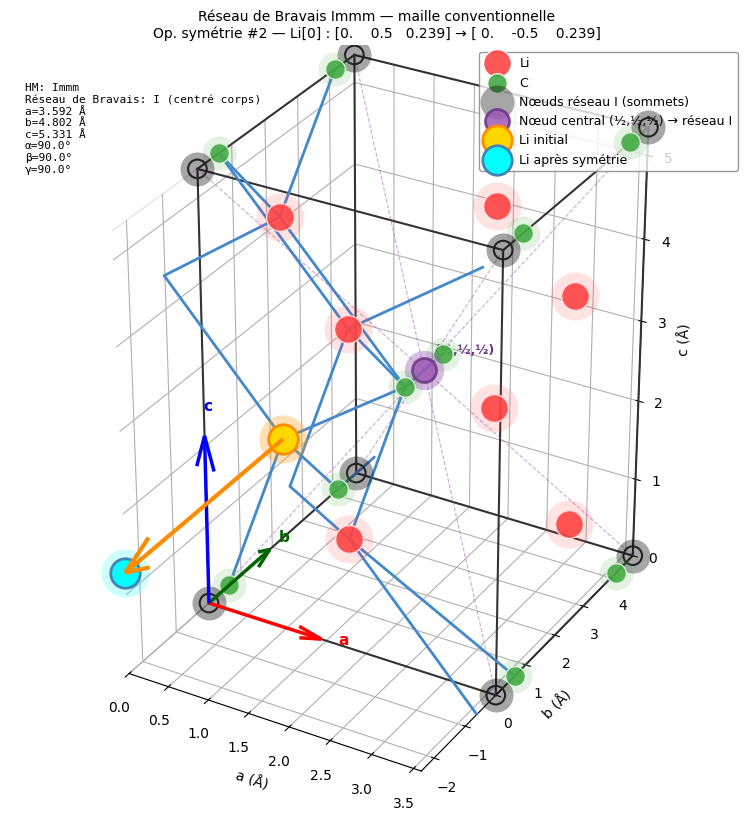

In [15]:
from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

sga      = SpacegroupAnalyzer(structure)
symmops  = sga.get_symmetry_operations()

i_atom   = 0
i_symmop = 2

symmop    = symmops[i_symmop]
pos_init  = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Atome  : {structure.sites[i_atom].species_string}")
print(f"Avant  : {np.round(pos_init, 4)}")
print(f"Après  : {np.round(pos_final, 4)}")

# ── Couleurs et tailles ────────────────────────────────────────────────────
couleurs = {"Li": "#FF4444", "C": "#44AA44"}
tailles  = {"Li": 400,       "C": 200}

# ── Figure fond BLANC ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8), facecolor="white")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")

# ── 1. Atomes avec réplication périodique sur la maille conventionnelle ───
# On génère tous les atomes visibles : ceux dans [0,1]³ + images aux frontières
def get_all_sites_with_images(structure):
    """
    Retourne la liste (coords_cart, elem, frac_coords_original) 
    pour tous les atomes visibles dans/sur la maille conventionnelle.
    On replique sur -1..1 et on garde ceux dont les coords fractionnaires
    tombent dans [-0.01, 1.01] (tolérance pour les atomes aux faces/sommets).
    """
    sites_to_draw = []
    for site in structure.sites:
        frac = site.frac_coords % 1.0  # ramène dans [0,1[
        elem = site.species_string
        # Générer les images dans {0,1} pour chaque coord fractionnaire proche de 0 ou 1
        images = [[frac[0]], [frac[1]], [frac[2]]]
        for k in range(3):
            if frac[k] < 0.01:
                images[k].append(1.0)
            if frac[k] > 0.99:
                images[k].append(0.0)
        for fx in images[0]:
            for fy in images[1]:
                for fz in images[2]:
                    cart = structure.lattice.get_cartesian_coords([fx, fy, fz])
                    sites_to_draw.append((cart, elem, np.array([fx, fy, fz])))
    return sites_to_draw

all_sites = get_all_sites_with_images(structure)

# ── 2. Liaisons ────────────────────────────────────────────────────────────
cnn = CrystalNN()
deja_traces = set()

for i, site in enumerate(structure.sites):
    try:
        for neighbor in cnn.get_nn_info(structure, i):
            j   = neighbor["site_index"]
            sj  = neighbor["site"]
            key = tuple(sorted([i, j]))
            if key not in deja_traces:
                deja_traces.add(key)
                ax.plot([site.coords[0], sj.coords[0]],
                        [site.coords[1], sj.coords[1]],
                        [site.coords[2], sj.coords[2]],
                        color="#4488CC", linewidth=2, zorder=1,
                        solid_capstyle="round")
    except:
        pass

# ── 3. Tracé des atomes répliqués ─────────────────────────────────────────
drawn_labels = set()
for cart, elem, frac in all_sites:
    x, y, z = cart
    label = elem if elem not in drawn_labels else "_nolegend_"
    drawn_labels.add(elem)
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 200),
               zorder=2,
               edgecolors="white",
               linewidths=1,
               label=label,
               alpha=0.9)
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 200) * 3,
               zorder=1,
               alpha=0.15,
               linewidths=0)

# ── 4. Nœuds du réseau de Bravais I (sommets + centre) ───────────────────
# Réseau I = nœuds aux 8 sommets (0,0,0) et au centre (½,½,½)
lattice = structure.lattice.matrix
vecs    = [lattice[0], lattice[1], lattice[2]]
origin  = np.array([0, 0, 0])

# 8 sommets de la maille conventionnelle
corners = np.array([
    i*vecs[0] + j*vecs[1] + k*vecs[2]
    for i in range(2) for j in range(2) for k in range(2)
])

# Centre (½,½,½) — nœud caractéristique du réseau I
center = 0.5*vecs[0] + 0.5*vecs[1] + 0.5*vecs[2]

# Tracé des nœuds du réseau de Bravais (grands cercles noirs transparents)
for idx, corner in enumerate(corners):
    label = "Nœuds réseau I (sommets)" if idx == 0 else "_nolegend_"
    ax.scatter(*corner, color="black", s=600, zorder=8,
               alpha=0.35, linewidths=0, label=label)
    ax.scatter(*corner, color="black", s=180, zorder=9,
               edgecolors="#222222", linewidths=1.5,
               facecolors="none", label="_nolegend_")

# Nœud central (½,½,½) — mis en évidence en violet
ax.scatter(*center, color="#9B59B6", s=800, zorder=8,
           alpha=0.4, linewidths=0, label="_nolegend_")
ax.scatter(*center, color="#9B59B6", s=300, zorder=9,
           edgecolors="#6C3483", linewidths=2,
           facecolors="#9B59B6", alpha=0.85,
           label="Nœud central (½,½,½) → réseau I")

# Annotation du nœud central
ax.text(center[0]+0.1, center[1]+0.1, center[2]+0.2,
        "(½,½,½)", fontsize=9, color="#6C3483", fontweight="bold", zorder=10)

# ── 5. Lignes reliant les sommets au centre (caractérisant le réseau I) ───
for corner in corners:
    ax.plot(*zip(corner, center),
            color="#9B59B6", linewidth=0.8, linestyle="--",
            alpha=0.5, zorder=3)

# ── 6. Atome initial (jaune) et final (cyan) ──────────────────────────────
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

ax.scatter(*coords_init, color="gold", s=1200,
           zorder=4, alpha=0.2, linewidths=0)
ax.scatter(*coords_init, color="gold", s=450,
           zorder=5, edgecolors="darkorange",
           linewidths=2, label="Li initial")

ax.scatter(*coords_final, color="cyan", s=1200,
           zorder=4, alpha=0.2, linewidths=0)
ax.scatter(*coords_final, color="cyan", s=450,
           zorder=5, edgecolors="steelblue",
           linewidths=2, label="Li après symétrie")

# ── 7. Flèche orange épaisse ──────────────────────────────────────────────
deplacement = coords_final - coords_init
ax.quiver(*coords_init, *deplacement,
          color="darkorange", linewidth=3,
          arrow_length_ratio=0.15, zorder=6)

# ── 8. Arêtes de la maille en gris foncé ──────────────────────────────────
edges = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end), color="#333333", linewidth=1.5, zorder=0)

# ── 9. Axes cristallographiques colorés ───────────────────────────────────
scale = 0.4
axes_colors = {"a": "red", "b": "darkgreen", "c": "blue"}
for vec, (label, color) in zip(vecs, axes_colors.items()):
    direction = vec / np.linalg.norm(vec) * scale * np.linalg.norm(vec)
    ax.quiver(*origin, *direction,
              color=color, linewidth=2.5,
              arrow_length_ratio=0.2, zorder=7)
    ax.text(*(origin + direction * 1.15),
            label, color=color, fontsize=11, fontweight="bold")

# ── 10. Proportions et limites ─────────────────────────────────────────────
lp = structure.lattice
ax.set_box_aspect([lp.a, lp.b, lp.c])

all_points = np.vstack([corners, center, coords_init, coords_final])
ax.set_xlim(all_points[:, 0].min(), all_points[:, 0].max())
ax.set_ylim(all_points[:, 1].min(), all_points[:, 1].max())
ax.set_zlim(all_points[:, 2].min(), all_points[:, 2].max())

# ── 11. Infos maille ──────────────────────────────────────────────────────
info = (f"HM: {structure.get_space_group_info()[0]}\n"
        f"Réseau de Bravais: I (centré corps)\n"
        f"a={lp.a:.3f} Å\nb={lp.b:.3f} Å\nc={lp.c:.3f} Å\n"
        f"α={lp.alpha:.1f}°\nβ={lp.beta:.1f}°\nγ={lp.gamma:.1f}°")
ax.text2D(0.02, 0.95, info, transform=ax.transAxes,
          fontsize=8, verticalalignment="top",
          fontfamily="monospace", color="black")

# ── 12. Légende et titre ──────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(),
          facecolor="white", edgecolor="gray", fontsize=9,
          loc="upper right")

ax.set_title(
    f"Réseau de Bravais Immm — maille conventionnelle\n"
    f"Op. symétrie #{i_symmop} — "
    f"{structure.sites[i_atom].species_string}[{i_atom}] : "
    f"{np.round(pos_init,3)} → {np.round(pos_final,3)}",
    fontsize=10, color="black"
)
ax.set_xlabel("a (Å)"); ax.set_ylabel("b (Å)"); ax.set_zlabel("c (Å)")
ax.tick_params(colors="black")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("#CCCCCC")
ax.yaxis.pane.set_edgecolor("#CCCCCC")
ax.zaxis.pane.set_edgecolor("#CCCCCC")
ax.grid(True, color="#EEEEEE", linewidth=0.5)

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=150, facecolor="white")
plt.show()

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Atome  : Li
Avant  : [0.     0.5    0.2393]
Après  : [ 0.     -0.5     0.2393]


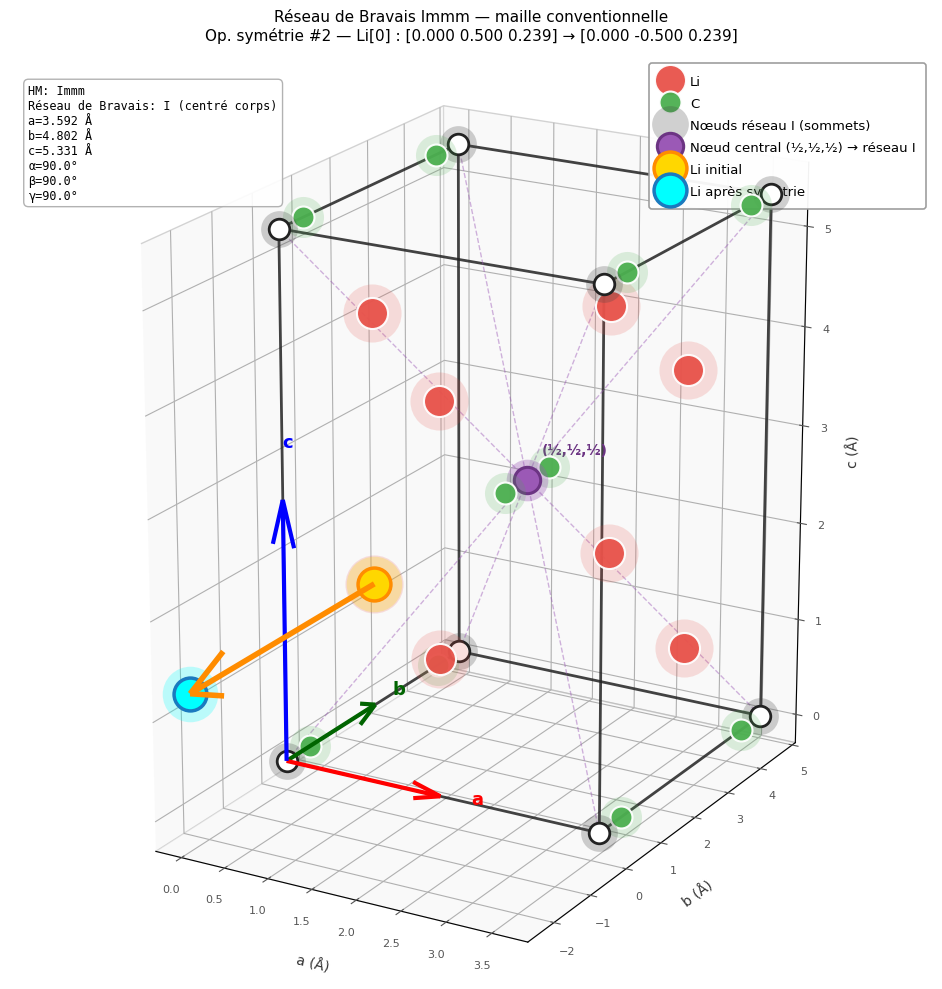

In [35]:
import scipy.interpolate as _si
if not hasattr(_si, 'make_splrep'):
    _si.make_splrep = _si.splrep

from mp_api.client import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.local_env import CrystalNN
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

sga     = SpacegroupAnalyzer(structure)
symmops = sga.get_symmetry_operations()

i_atom   = 0
i_symmop = 2
symmop    = symmops[i_symmop]
pos_init  = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Atome  : {structure.sites[i_atom].species_string}")
print(f"Avant  : {np.round(pos_init, 4)}")
print(f"Après  : {np.round(pos_final, 4)}")

# ── Couleurs et tailles ────────────────────────────────────────────────────
couleurs = {"Li": "#E8524A", "C": "#4CAF50"}   # rouge vif / vert vif
tailles  = {"Li": 500,       "C": 250}

# ── Figure fond BLANC ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 10), facecolor="white")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")

# Angle de vue proche de l'image de référence
ax.view_init(elev=20, azim=-60)

# ── Panneaux avec grille visible (style image droite) ─────────────────────
ax.xaxis.pane.fill = True
ax.yaxis.pane.fill = True
ax.zaxis.pane.fill = True
ax.xaxis.pane.set_facecolor("#F5F5F5")
ax.yaxis.pane.set_facecolor("#F5F5F5")
ax.zaxis.pane.set_facecolor("#F5F5F5")
ax.xaxis.pane.set_edgecolor("#AAAAAA")
ax.yaxis.pane.set_edgecolor("#AAAAAA")
ax.zaxis.pane.set_edgecolor("#AAAAAA")
ax.grid(True, color="#CCCCCC", linewidth=0.8, linestyle="-")

# ── 1. Atomes répliqués ────────────────────────────────────────────────────
def get_all_sites_with_images(structure):
    sites_to_draw = []
    for site in structure.sites:
        frac = site.frac_coords % 1.0
        elem = site.species_string
        images = [[frac[0]], [frac[1]], [frac[2]]]
        for k in range(3):
            if frac[k] < 0.01:
                images[k].append(1.0)
            if frac[k] > 0.99:
                images[k].append(0.0)
        for fx in images[0]:
            for fy in images[1]:
                for fz in images[2]:
                    cart = structure.lattice.get_cartesian_coords([fx, fy, fz])
                    sites_to_draw.append((cart, elem, np.array([fx, fy, fz])))
    return sites_to_draw

all_sites = get_all_sites_with_images(structure)


# ── 3. Tracé des atomes ────────────────────────────────────────────────────
drawn_labels = set()
for cart, elem, frac in all_sites:
    x, y, z = cart
    label = elem if elem not in drawn_labels else "_nolegend_"
    drawn_labels.add(elem)
    # Halo large semi-transparent
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 250) * 3.5,
               zorder=1, alpha=0.18, linewidths=0)
    # Atome principal avec contour blanc
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "gray"),
               s=tailles.get(elem, 250),
               zorder=2,
               edgecolors="white", linewidths=1.5,
               label=label, alpha=0.95)

# ── 4. Nœuds du réseau de Bravais I ───────────────────────────────────────
lattice = structure.lattice.matrix
vecs    = [lattice[0], lattice[1], lattice[2]]
origin  = np.array([0, 0, 0])

corners = np.array([
    i*vecs[0] + j*vecs[1] + k*vecs[2]
    for i in range(2) for j in range(2) for k in range(2)
])
center = 0.5*vecs[0] + 0.5*vecs[1] + 0.5*vecs[2]

for idx, corner in enumerate(corners):
    label = "Nœuds réseau I (sommets)" if idx == 0 else "_nolegend_"
    # Halo gris
    ax.scatter(*corner, color="#444444", s=700, zorder=8,
               alpha=0.25, linewidths=0, label=label)
    # Cercle avec contour bien visible
    ax.scatter(*corner, color="white", s=220, zorder=9,
               edgecolors="#222222", linewidths=2.0)

# Nœud central (½,½,½) — violet bien visible
ax.scatter(*center, color="#9B59B6", s=900, zorder=8,
           alpha=0.35, linewidths=0)
ax.scatter(*center, color="#9B59B6", s=360, zorder=9,
           edgecolors="#6C3483", linewidths=2.2,
           label="Nœud central (½,½,½) → réseau I")

ax.text(center[0]+0.12, center[1]+0.12, center[2]+0.25,
        "(½,½,½)", fontsize=10, color="#6C3483",
        fontweight="bold", zorder=10)

# ── 5. Lignes vers le centre (réseau I) ───────────────────────────────────
for corner in corners:
    ax.plot(*zip(corner, center),
            color="#9B59B6", linewidth=1.0, linestyle="--",
            alpha=0.45, zorder=3)

# ── 6. Atome initial (jaune) et final (cyan) ──────────────────────────────
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

# Initial — jaune/orange, halo large
ax.scatter(*coords_init, color="gold", s=1600,
           zorder=4, alpha=0.25, linewidths=0)
ax.scatter(*coords_init, color="gold", s=560,
           zorder=5, edgecolors="darkorange",
           linewidths=2.5, label="Li initial")

# Final — cyan, halo large
ax.scatter(*coords_final, color="cyan", s=1600,
           zorder=4, alpha=0.25, linewidths=0)
ax.scatter(*coords_final, color="cyan", s=560,
           zorder=5, edgecolors="#1A7ABF",
           linewidths=2.5, label="Li après symétrie")

# ── 7. Flèche de déplacement (épaisse, orange) ────────────────────────────
deplacement = coords_final - coords_init
ax.quiver(*coords_init, *deplacement,
          color="darkorange", linewidth=4,
          arrow_length_ratio=0.18, zorder=6)

# ── 8. Arêtes de la maille (noir/gris foncé) ──────────────────────────────
edges = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end),
            color="#222222", linewidth=2.0, zorder=0, alpha=0.85)

# ── 9. Axes cristallographiques colorés et allongés ───────────────────────
scale = 0.5   # plus long que 0.4
axes_colors = {"a": "red", "b": "darkgreen", "c": "blue"}
for vec, (label_ax, color) in zip(vecs, axes_colors.items()):
    direction = vec / np.linalg.norm(vec) * scale * np.linalg.norm(vec)
    ax.quiver(*origin, *direction,
              color=color, linewidth=3.0,
              arrow_length_ratio=0.18, zorder=7)
    ax.text(*(origin + direction * 1.2),
            label_ax, color=color, fontsize=13, fontweight="bold")

# ── 10. Proportions et limites ─────────────────────────────────────────────
lp = structure.lattice
ax.set_box_aspect([lp.a, lp.b, lp.c])

all_points = np.vstack([corners, center, coords_init, coords_final])
margin = 0.3
ax.set_xlim(all_points[:, 0].min() - margin, all_points[:, 0].max() + margin)
ax.set_ylim(all_points[:, 1].min() - margin, all_points[:, 1].max() + margin)
ax.set_zlim(all_points[:, 2].min() - margin, all_points[:, 2].max() + margin)

# ── 11. Infos maille dans un cadre (coin haut gauche) ─────────────────────
info = (f"HM: {structure.get_space_group_info()[0]}\n"
        f"Réseau de Bravais: I (centré corps)\n"
        f"a={lp.a:.3f} Å\nb={lp.b:.3f} Å\nc={lp.c:.3f} Å\n"
        f"α={lp.alpha:.1f}°\nβ={lp.beta:.1f}°\nγ={lp.gamma:.1f}°")
ax.text2D(0.02, 0.97, info,
          transform=ax.transAxes,
          fontsize=8.5,
          verticalalignment="top",
          fontfamily="monospace",
          color="black",
          bbox=dict(boxstyle="round,pad=0.4",
                    facecolor="white",
                    edgecolor="#AAAAAA",
                    alpha=0.90,
                    linewidth=1.0))

# ── 12. Légende stylisée (coin haut droit, image de référence) ────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

legend = ax.legend(
    unique.values(), unique.keys(),
    facecolor="white",
    edgecolor="#999999",
    fontsize=9.5,
    loc="upper right",
    framealpha=0.95,
    borderpad=0.8,
    labelspacing=0.6,
    handlelength=1.5,
    handleheight=1.2,
    borderaxespad=0.5,
    fancybox=True,          # coins arrondis comme l'image droite
    shadow=False,
)
legend.get_frame().set_linewidth(1.2)

# ── 13. Titre détaillé (deux lignes) ──────────────────────────────────────
ax.set_title(
    f"Réseau de Bravais Immm — maille conventionnelle\n"
    f"Op. symétrie #{i_symmop} — "
    f"{structure.sites[i_atom].species_string}[{i_atom}] : "
    f"[{' '.join(f'{v:.3f}' for v in np.round(pos_init,3))}]"
    f" → [{' '.join(f'{v:.3f}' for v in np.round(pos_final,3))}]",
    fontsize=11,
    color="black",
    pad=12,
)

# ── 14. Axes avec labels et ticks lisibles ────────────────────────────────
ax.set_xlabel("a (Å)", fontsize=10, labelpad=8, color="#333333")
ax.set_ylabel("b (Å)", fontsize=10, labelpad=8, color="#333333")
ax.set_zlabel("c (Å)", fontsize=10, labelpad=8, color="#333333")
ax.tick_params(colors="#555555", labelsize=8)

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=180, facecolor="white",
            bbox_inches="tight")
plt.show()

## 2. Réseau direct et réciproque

In [23]:
import numpy as np

lattice = structure.lattice
a1, a2, a3 = lattice.matrix
reciprocal_lattice = lattice.reciprocal_lattice.matrix

print("Vecteurs réseau direct:")
print(a1, a2, a3)

print("Vecteurs réseau réciproque:")
print(reciprocal_lattice)

# #représentation des réseaux
# # reseau direct
#fig = plt.figure()
#ax = fig.add_subplot(111, projection='3d')

# # Origine
#origin = [0, 0, 0]

# # Tracé des vecteurs
#ax.quiver(*origin, *a1, length=1, normalize=False)
#ax.quiver(*origin, *a2, length=1, normalize=False)
#ax.quiver(*origin, *a3, length=1, normalize=False)

# # Labels
#ax.text(*a1, "a1")
#ax.text(*a2, "a2")
#ax.text(*a3, "a3")

#ax.set_xlabel("X")
#ax.set_ylabel("Y")
#ax.set_zlabel("Z")

#plt.show()

# # reseau reciproque
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# # Tracé des vecteurs
# ax.quiver(*origin, *reciprocal_lattice[0], length=1, normalize=False)
# ax.quiver(*origin, *reciprocal_lattice[1], length=1, normalize=False)
# ax.quiver(*origin, *reciprocal_lattice[2], length=1, normalize=False)

# # Labels
# ax.text(*reciprocal_lattice[0], "b1")
# ax.text(*reciprocal_lattice[1], "b2")
# ax.text(*reciprocal_lattice[2], "b3")

# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")

# plt.show()


Vecteurs réseau direct:
[3.59152978e+00 0.00000000e+00 2.19917772e-16] [7.72217565e-16 4.80198177e+00 2.94036580e-16] [0.         0.         5.33075611]
Vecteurs réseau réciproque:
[[ 1.74944542e+00 -2.81332280e-16  0.00000000e+00]
 [ 0.00000000e+00  1.30845672e+00  0.00000000e+00]
 [-7.21725269e-17 -7.21725269e-17  1.17866681e+00]]


## 3. Type de maille, système cristallin, groupe ponctuel

In [13]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

sga = SpacegroupAnalyzer(structure)

print("Système cristallin:", sga.get_crystal_system())
print("Type de maille:", sga.get_lattice_type())
print("Groupe ponctuel:", sga.get_space_group_symbol())

Système cristallin: orthorhombic
Type de maille: orthorhombic
Groupe ponctuel: Immm


## 4. Application de trois éléments de symétrie

Pour les systèmes orthorhombiques, les trois caractères décrivent la 
symétrie le long des trois axes, a, b, et c.
Groupe ponctuel: mmm 
ici on nous dit qu'il y a des symétries le long des trois axes (1)
première dircetion de symétrie : 
maille conventionnelle est orthorhombic

Le système orthorhombique possède trois directions de symétrie perpendiculaires entre elles, le long desquelles se trouvent au moins un axe de rotation d'ordre 2 ou un plan miroir.(1) 

les vecteurs de base a et b étant équivalents par la rotation d'ordre 4, les directions [10] et [01] le sont aussi. À tout élément de symétrie trouvé dans la deuxième direction de symétrie [10] correspond un élément de même symétrie dans la direction [01]. Par exemple, si une droite miroir est perpendiculaire à a dans un cristal tétragonal, alors il existe une droite miroir perpendiculaire à b. La deuxième direction de symétrie s'écrit <10> pour montrer qu'il s'agit d'une famille de directions équivalentes. D'autre part, comme a=b, il est aussi possible d'avoir une droite miroir perpendiculaire à la direction [11]. La troisième direction de symétrie du système tétragonal est la direction <11>

In [5]:


sga = SpacegroupAnalyzer(structure)
struc_conv = sga.get_conventional_standard_structure()
sga_conv = SpacegroupAnalyzer(struc_conv)
sym_ops = sga_conv.get_symmetry_operations(cartesian=False)

sym_ops_no_identity = [op for op in sym_ops
    if not (np.allclose(op.rotation_matrix, np.eye(3), atol=1e-5) and
            np.allclose(op.translation_vector, 0, atol=1e-5))]

def verifier_operation(W, tol=1e-5):
    """Vérifie toutes les conditions d'une opération de symétrie valide."""
    
    resultats = {}

    # Condition 1 : |det| = 1
    det = np.linalg.det(W)
    resultats["det=±1"] = np.isclose(abs(det), 1.0, atol=tol)

    # Condition 2 : Orthogonalité (W^T W = I)
    WtW = W.T @ W
    resultats["orthogonale"] = np.allclose(WtW, np.eye(3), atol=tol)

    # Condition 3 : Éléments ∈ {-1, 0, +1} uniquement
    elements_valides = np.all(
        np.isclose(W, 0, atol=tol) |
        np.isclose(W, 1, atol=tol) |
        np.isclose(W, -1, atol=tol)
    )
    resultats["elements∈{-1,0,1}"] = elements_valides

    #  Condition 4 : Un seul ±1 par ligne ET par colonne (matrice de permutation signée)
    non_nuls_par_ligne   = np.sum(~np.isclose(W, 0, atol=tol), axis=1)
    non_nuls_par_colonne = np.sum(~np.isclose(W, 0, atol=tol), axis=0)
    resultats["permutation_signee"] = (
        np.all(non_nuls_par_ligne == 1) and
        np.all(non_nuls_par_colonne == 1)
    )

    # Validité globale
    resultats["valide"] = all(resultats.values())
    return resultats, round(det)

# --- Affichage ---
for i, op in enumerate(sym_ops_no_identity):
    W = op.rotation_matrix.astype(float)
    mat = np.round(W, decimals=3)
    checks, det = verifier_operation(W)

    type_op = 'propre' if det == 1 else 'impropre'
    statut   = " VALIDE" if checks["valide"] else "INVALIDE"

    print(f"\n--- Opération {i} --- det={det} ({type_op}) → {statut}")
    print(mat)
    print("Vecteur de translation:", np.round(op.translation_vector, decimals=3))

    if not checks["valide"]:
        print("  Conditions échouées :")
        for cond, ok in checks.items():
            if cond != "valide" and not ok:
                print(f"    ✗ {cond}")


--- Opération 0 --- det=-1 (impropre) →  VALIDE
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 1 --- det=1 (propre) →  VALIDE
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 2 --- det=-1 (impropre) →  VALIDE
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 3 --- det=1 (propre) →  VALIDE
[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 4 --- det=-1 (impropre) →  VALIDE
[[-1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 5 --- det=1 (propre) →  VALIDE
[[-1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 6 --- det=-1 (impropre) →  VALIDE
[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]
Vecteur de translation: [0. 0. 0.]

--- Opération 7 --- det=1 (propre) →  VALIDE
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Vecteur de trans

### Premier opération de symétrie


(Brouillon)

On va avec le Lithum en premier ( quid de la position )
Inversion -> opération de la deuxième espèce <=> inversion de la chiralité 

(x,y,z) -> (-x,-y,-z)


avec un vecteur de translation tau ( lettre grec) [0,0,0], la symétrie est symmorphique, on est en ineversion pure 


In [6]:
i_symmop = 0
symmop = sym_ops_no_identity[i_symmop]
#matrice de rotation
print("Matrice de rotation:")
print(np.round(symmop.rotation_matrix.astype(float), decimals=3))

#coordonnées de l'atome de lithium avant et après l'opération de symétrie
Li_pos = struc_conv.sites[0].frac_coords
Li_pos_sym = symmop.operate(Li_pos)
print(f"Coordonnées de l'atome de lithium avant l'opération de symétrie: {Li_pos}")
print(f"Coordonnées de l'atome de lithium après l'opération de symétrie: {Li_pos_sym}")

Matrice de rotation:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Coordonnées de l'atome de lithium avant l'opération de symétrie: [0.         0.5        0.23930556]
Coordonnées de l'atome de lithium après l'opération de symétrie: [ 0.         -0.5        -0.23930556]


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Opération : Rot:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
tau
[0. 0. 0.]
Atome     : Li
Avant     : [0.     0.5    0.2393]
Après     : [ 0.     -0.5    -0.2393]
Après %1  : [0.     0.5    0.7607]


c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


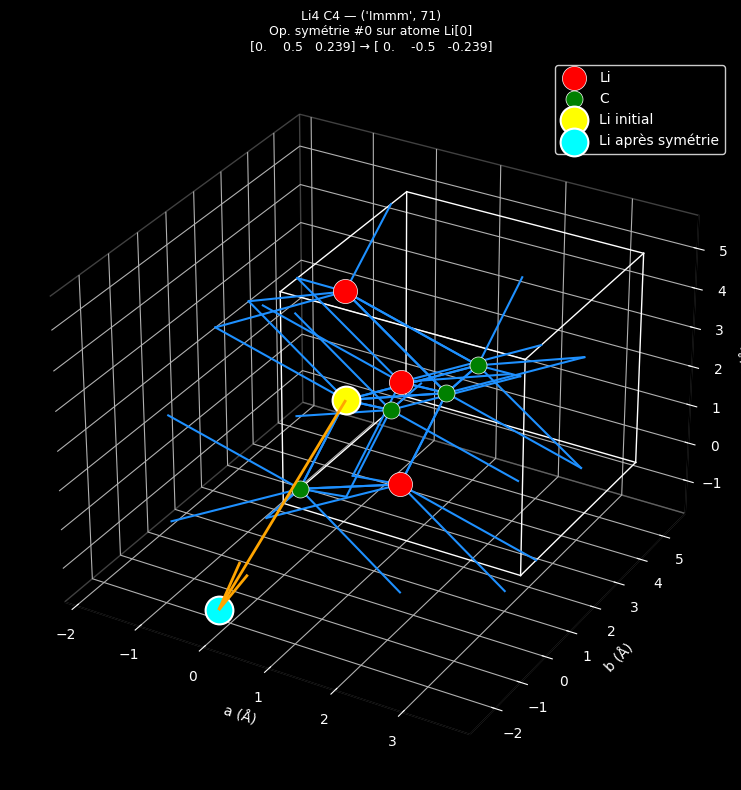

In [7]:

from pymatgen.analysis.local_env import CrystalNN
from mpl_toolkits.mplot3d import Axes3D


API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

# Récupérer les opérations de symétrie
sga = SpacegroupAnalyzer(structure)
symmops = sga.get_symmetry_operations()

# Choisir un atome et une opération de symétrie
i_atom  = 0   # index de l'atome Li

i_symmop = 0
symmop = sym_ops_no_identity[i_symmop]

pos_init = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Opération : {symmop}")
print(f"Atome     : {structure.sites[i_atom].species_string}")
print(f"Avant     : {np.round(pos_init, 4)}")
print(f"Après     : {np.round(pos_final, 4)}")
print(f"Après %1  : {np.round(pos_final % 1, 4)}")

# ── Visualisation ──────────────────────────────────────────────────────────
couleurs = {"Li": "red", "C": "green"}
tailles  = {"Li": 300,   "C": 150}

fig = plt.figure(figsize=(10, 8), facecolor="black")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("black")

# ── 1. Liaisons ────────────────────────────────────────────────────────────
cnn = CrystalNN()
for i, site in enumerate(structure.sites):
    try:
        for neighbor in cnn.get_nn_info(structure, i):
            sj = neighbor["site"]
            ax.plot([site.coords[0], sj.coords[0]],
                    [site.coords[1], sj.coords[1]],
                    [site.coords[2], sj.coords[2]],
                    color="dodgerblue", linewidth=1.5, zorder=1)
    except:
        pass

# ── 2. Tous les atomes (structure inchangée) ───────────────────────────────
for i, site in enumerate(structure.sites):
    elem = site.species_string
    x, y, z = site.coords
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "white"),
               s=tailles.get(elem, 150),
               zorder=2,
               edgecolors="white",
               linewidths=0.5,
               label=elem)

# ── 3. Montrer le mapping de l'atome choisi ────────────────────────────────
# Position initiale (surlignée en jaune)
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

ax.scatter(*coords_init, color="yellow", s=400,
           zorder=5, edgecolors="white", linewidths=1.5,
           label=f"Li initial")

# Position finale (surlignée en cyan)
ax.scatter(*coords_final, color="cyan", s=400,
           zorder=5, edgecolors="white", linewidths=1.5,
           label=f"Li après symétrie")

# Flèche de déplacement
ax.quiver(*coords_init,
          *(coords_final - coords_init),
          color="orange", linewidth=2, arrow_length_ratio=0.2,
          zorder=6)

# ── 4. Arêtes de la maille ─────────────────────────────────────────────────
lattice = structure.lattice.matrix
vecs   = [lattice[0], lattice[1], lattice[2]]
origin = np.array([0, 0, 0])
edges  = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end), color="white", linewidth=1, zorder=0)

# ── 5. Légende et titre ────────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(),
          facecolor="black", labelcolor="white", edgecolor="white")

lp = structure.lattice
ax.set_title(
    f"{structure.formula} — {structure.get_space_group_info()}\n"
    f"Op. symétrie #{i_symmop} sur atome {structure.sites[i_atom].species_string}[{i_atom}]\n"
    f"{np.round(pos_init,3)} → {np.round(pos_final,3)}",
    color="white", fontsize=9
)
ax.set_xlabel("a (Å)", color="white")
ax.set_ylabel("b (Å)", color="white")
ax.set_zlabel("c (Å)", color="white")
ax.tick_params(colors="white")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("gray")
ax.yaxis.pane.set_edgecolor("gray")
ax.zaxis.pane.set_edgecolor("gray")

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=150, facecolor="black")
plt.show()

Pour savoir les poistions des atomes

In [5]:
sites = struc_conv.sites
for i in range(len(sites)):
     print(f"Atome {i}: {sites[i].specie}, \n Coordonnées fractionnaires: {sites[i].frac_coords}, \n Coordonnées cartésiennes :{struc_conv.lattice.get_cartesian_coords(sites[i].frac_coords)}")
    
Li_pos = sites[0].frac_coords
C_pos = sites[6].frac_coords


Atome 0: Li, 
 Coordonnées fractionnaires: [0.         0.5        0.23930556], 
 Coordonnées cartésiennes :[3.86108782e-16 2.40099089e+00 1.27567958e+00]
Atome 1: Li, 
 Coordonnées fractionnaires: [0.         0.5        0.76069444], 
 Coordonnées cartésiennes :[3.86108782e-16 2.40099089e+00 4.05507653e+00]
Atome 2: Li, 
 Coordonnées fractionnaires: [0.5        0.         0.73930556], 
 Coordonnées cartésiennes :[1.79576489 0.         3.94105763]
Atome 3: Li, 
 Coordonnées fractionnaires: [0.5        0.         0.26069444], 
 Coordonnées cartésiennes :[1.79576489 0.         1.38969848]
Atome 4: C, 
 Coordonnées fractionnaires: [0.         0.86974406 0.        ], 
 Coordonnées cartésiennes :[6.71631640e-16 4.17649512e+00 2.55736569e-16]
Atome 5: C, 
 Coordonnées fractionnaires: [0.         0.13025594 0.        ], 
 Coordonnées cartésiennes :[1.00585925e-16 6.25486649e-01 3.83000112e-17]
Atome 6: C, 
 Coordonnées fractionnaires: [0.5        0.36974406 0.5       ], 
 Coordonnées cartésienn

il y a alors des symétries le long des directions [100],[010] et [0,0,1]

### Deuxième opération de symmétrie 

Deuxième opération de symétrie qu'on décide d'appliquer sur l'atome de carbone 


 Opération numero trois 


[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]

 
Vecteur de translation: [0. 0. 0.] et det 1 pas d'inversion de chiralité si j'ai bien compris 
Il s'agit du rotation autour de x !!!


In [8]:
i_symmop = 3
symmop = sym_ops_no_identity[i_symmop]
#matrice de rotation
print("Matrice de rotation:")
print(np.round(symmop.rotation_matrix.astype(float), decimals=3))

#coordonnées de l'atome de carbone avant et après l'opération de symétrie
C_pos = struc_conv.sites[6].frac_coords
C_pos_sym = symmop.operate(C_pos)
print(f"Coordonnées de l'atome de carbone avant l'opération de symétrie: {C_pos}")
print(f"Coordonnées de l'atome de carbone après l'opération de symétrie: {C_pos_sym}")

Matrice de rotation:
[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
Coordonnées de l'atome de carbone avant l'opération de symétrie: [0.5        0.36974406 0.5       ]
Coordonnées de l'atome de carbone après l'opération de symétrie: [ 0.5        -0.36974406 -0.5       ]


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Opération : Rot:
[[ 1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]
tau
[0. 0. 0.]
Atome     : C
Avant     : [0.5    0.3697 0.5   ]
Après     : [ 0.5    -0.3697 -0.5   ]
Après %1  : [0.5    0.6303 0.5   ]


c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


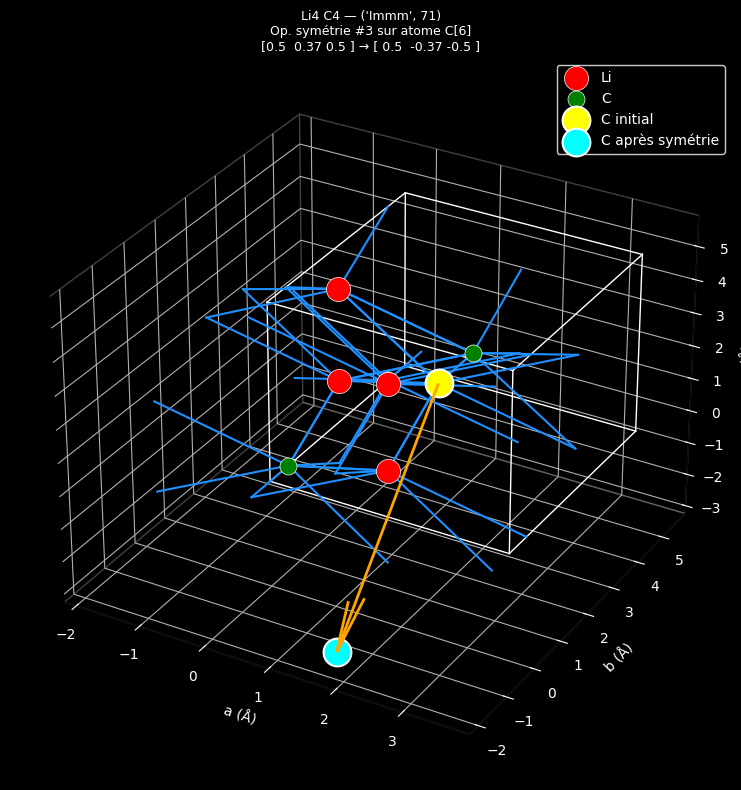

In [8]:

from pymatgen.analysis.local_env import CrystalNN
from mpl_toolkits.mplot3d import Axes3D


API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

# Récupérer les opérations de symétrie
sga = SpacegroupAnalyzer(structure)
symmops = sga.get_symmetry_operations()

# Choisir un atome et une opération de symétrie
i_atom  = 6   # index de l'atome C

i_symmop = 3
symmop = sym_ops_no_identity[i_symmop]

pos_init = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Opération : {symmop}")
print(f"Atome     : {structure.sites[i_atom].species_string}")
print(f"Avant     : {np.round(pos_init, 4)}")
print(f"Après     : {np.round(pos_final, 4)}")
print(f"Après %1  : {np.round(pos_final % 1, 4)}")

# ── Visualisation ──────────────────────────────────────────────────────────
couleurs = {"Li": "red", "C": "green"}
tailles  = {"Li": 300,   "C": 150}

fig = plt.figure(figsize=(10, 8), facecolor="black")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("black")

# ── 1. Liaisons ────────────────────────────────────────────────────────────
cnn = CrystalNN()
for i, site in enumerate(structure.sites):
    try:
        for neighbor in cnn.get_nn_info(structure, i):
            sj = neighbor["site"]
            ax.plot([site.coords[0], sj.coords[0]],
                    [site.coords[1], sj.coords[1]],
                    [site.coords[2], sj.coords[2]],
                    color="dodgerblue", linewidth=1.5, zorder=1)
    except:
        pass

# ── 2. Tous les atomes (structure inchangée) ───────────────────────────────
for i, site in enumerate(structure.sites):
    elem = site.species_string
    x, y, z = site.coords
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "white"),
               s=tailles.get(elem, 150),
               zorder=2,
               edgecolors="white",
               linewidths=0.5,
               label=elem)

# ── 3. Montrer le mapping de l'atome choisi ────────────────────────────────
# Position initiale (surlignée en jaune)
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

ax.scatter(*coords_init, color="yellow", s=400,
           zorder=5, edgecolors="white", linewidths=1.5,
           label=f"C initial")

# Position finale (surlignée en cyan)
ax.scatter(*coords_final, color="cyan", s=400,
           zorder=5, edgecolors="white", linewidths=1.5,
           label=f"C après symétrie")

# Flèche de déplacement
ax.quiver(*coords_init,
          *(coords_final - coords_init),
          color="orange", linewidth=2, arrow_length_ratio=0.2,
          zorder=6)

# ── 4. Arêtes de la maille ─────────────────────────────────────────────────
lattice = structure.lattice.matrix
vecs   = [lattice[0], lattice[1], lattice[2]]
origin = np.array([0, 0, 0])
edges  = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end), color="white", linewidth=1, zorder=0)

# ── 5. Légende et titre ────────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(),
          facecolor="black", labelcolor="white", edgecolor="white")

lp = structure.lattice
ax.set_title(
    f"{structure.formula} — {structure.get_space_group_info()}\n"
    f"Op. symétrie #{i_symmop} sur atome {structure.sites[i_atom].species_string}[{i_atom}]\n"
    f"{np.round(pos_init,3)} → {np.round(pos_final,3)}",
    color="white", fontsize=9
)
ax.set_xlabel("a (Å)", color="white")
ax.set_ylabel("b (Å)", color="white")
ax.set_zlabel("c (Å)", color="white")
ax.tick_params(colors="white")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("gray")
ax.yaxis.pane.set_edgecolor("gray")
ax.zaxis.pane.set_edgecolor("gray")

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=150, facecolor="black")
plt.show()

#### Troisième opération de symmétrie

inserer un peu d'explication

Il s'agit d'une reflexion, ici transfromation miroir perpendiculaire.


ici on a que tau vaut [0.5,0.5,0.5] parce qu'on a un glissement 

In [9]:
i_symmop = 10
symmop = sym_ops_no_identity[i_symmop]
#matrice de rotation
print("Matrice de rotation:")
print(np.round(symmop.rotation_matrix.astype(float), decimals=3))

#coordonnées de l'atome de lithium avant et après l'opération de symétrie
Li_pos = struc_conv.sites[0].frac_coords
Li_pos_sym = symmop.operate(Li_pos)
print(f"Coordonnées de l'atome de lithium avant l'opération de symétrie: {Li_pos}")
print(f"Coordonnées de l'atome de lithium après l'opération de symétrie: {Li_pos_sym}")

Matrice de rotation:
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]
Coordonnées de l'atome de lithium avant l'opération de symétrie: [0.         0.5        0.23930556]
Coordonnées de l'atome de lithium après l'opération de symétrie: [0.5        1.         0.26069444]


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Opération : Rot:
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]
tau
[0.5 0.5 0.5]
Atome     : Li
Avant     : [0.     0.5    0.2393]
Après     : [0.5    1.     0.2607]
Après %1  : [0.5    0.     0.2607]


c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
c:\Users\yousr\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pymatgen\analysis\local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


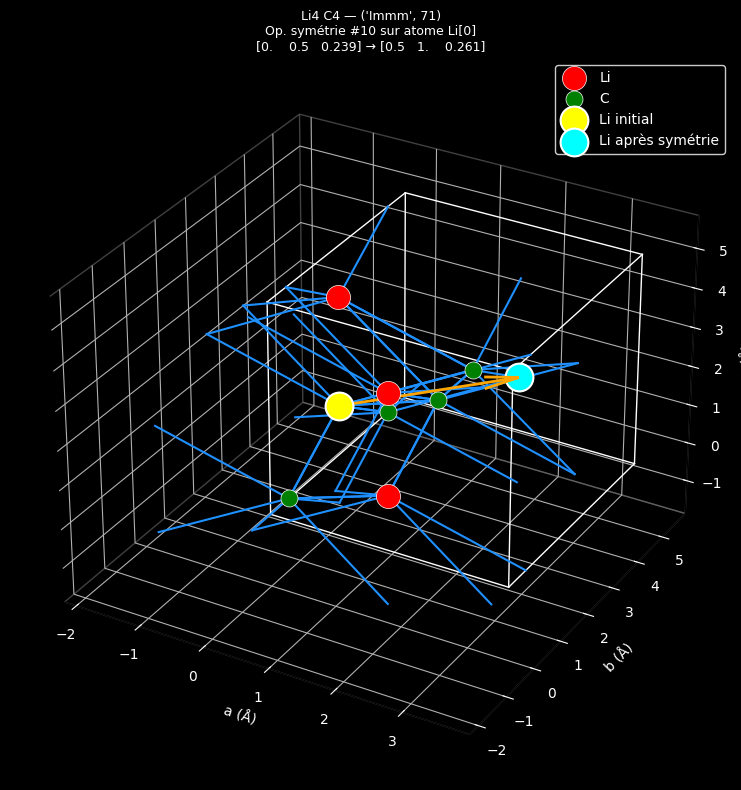

In [10]:

from pymatgen.analysis.local_env import CrystalNN
from mpl_toolkits.mplot3d import Axes3D


API_KEY = "PXBFSqNjWuCbMDn152B5RsMt61dfXOLI"
material_id = "mp-1378"

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(
        material_id, conventional_unit_cell=True
    )

# Récupérer les opérations de symétrie
sga = SpacegroupAnalyzer(structure)
symmops = sga.get_symmetry_operations()

# Choisir un atome et une opération de symétrie
i_atom  = 0   # index de l'atome Li

i_symmop = 10
symmop = sym_ops_no_identity[i_symmop]

pos_init = structure.sites[i_atom].frac_coords
pos_final = symmop.operate(pos_init)

print(f"Opération : {symmop}")
print(f"Atome     : {structure.sites[i_atom].species_string}")
print(f"Avant     : {np.round(pos_init, 4)}")
print(f"Après     : {np.round(pos_final, 4)}")
print(f"Après %1  : {np.round(pos_final % 1, 4)}")

# ── Visualisation ──────────────────────────────────────────────────────────
couleurs = {"Li": "red", "C": "green"}
tailles  = {"Li": 300,   "C": 150}

fig = plt.figure(figsize=(10, 8), facecolor="black")
ax  = fig.add_subplot(111, projection="3d")
ax.set_facecolor("black")

# ── 1. Liaisons ────────────────────────────────────────────────────────────
cnn = CrystalNN()
for i, site in enumerate(structure.sites):
    try:
        for neighbor in cnn.get_nn_info(structure, i):
            sj = neighbor["site"]
            ax.plot([site.coords[0], sj.coords[0]],
                    [site.coords[1], sj.coords[1]],
                    [site.coords[2], sj.coords[2]],
                    color="dodgerblue", linewidth=1.5, zorder=1)
    except:
        pass

# ── 2. Tous les atomes (structure inchangée) ───────────────────────────────
for i, site in enumerate(structure.sites):
    elem = site.species_string
    x, y, z = site.coords
    ax.scatter(x, y, z,
               color=couleurs.get(elem, "white"),
               s=tailles.get(elem, 150),
               zorder=2,
               edgecolors="white",
               linewidths=0.5,
               label=elem)

# ── 3. Montrer le mapping de l'atome choisi ────────────────────────────────
# Position initiale (surlignée en jaune)
coords_init  = structure.lattice.get_cartesian_coords(pos_init)
coords_final = structure.lattice.get_cartesian_coords(pos_final)

ax.scatter(*coords_init, color="yellow", s=400,
           zorder=5, edgecolors="white", linewidths=1.5,
           label=f"Li initial")

# Position finale (surlignée en cyan)
ax.scatter(*coords_final, color="cyan", s=400,
           zorder=5, edgecolors="white", linewidths=1.5,
           label=f"Li après symétrie")

# Flèche de déplacement
ax.quiver(*coords_init,
          *(coords_final - coords_init),
          color="orange", linewidth=2, arrow_length_ratio=0.2,
          zorder=6)

# ── 4. Arêtes de la maille ─────────────────────────────────────────────────
lattice = structure.lattice.matrix
vecs   = [lattice[0], lattice[1], lattice[2]]
origin = np.array([0, 0, 0])
edges  = [
    (origin,          vecs[0]),
    (origin,          vecs[1]),
    (origin,          vecs[2]),
    (vecs[0],         vecs[0]+vecs[1]),
    (vecs[0],         vecs[0]+vecs[2]),
    (vecs[1],         vecs[1]+vecs[0]),
    (vecs[1],         vecs[1]+vecs[2]),
    (vecs[2],         vecs[2]+vecs[0]),
    (vecs[2],         vecs[2]+vecs[1]),
    (vecs[0]+vecs[1], vecs[0]+vecs[1]+vecs[2]),
    (vecs[0]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
    (vecs[1]+vecs[2], vecs[0]+vecs[1]+vecs[2]),
]
for start, end in edges:
    ax.plot(*zip(start, end), color="white", linewidth=1, zorder=0)

# ── 5. Légende et titre ────────────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(),
          facecolor="black", labelcolor="white", edgecolor="white")

lp = structure.lattice
ax.set_title(
    f"{structure.formula} — {structure.get_space_group_info()}\n"
    f"Op. symétrie #{i_symmop} sur atome {structure.sites[i_atom].species_string}[{i_atom}]\n"
    f"{np.round(pos_init,3)} → {np.round(pos_final,3)}",
    color="white", fontsize=9
)
ax.set_xlabel("a (Å)", color="white")
ax.set_ylabel("b (Å)", color="white")
ax.set_zlabel("c (Å)", color="white")
ax.tick_params(colors="white")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("gray")
ax.yaxis.pane.set_edgecolor("gray")
ax.zaxis.pane.set_edgecolor("gray")

plt.tight_layout()
plt.savefig("Op_symetrie.png", dpi=150, facecolor="black")
plt.show()

## 5. Visualisation de la zone de Brillouin

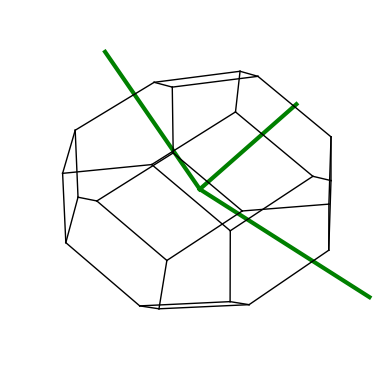

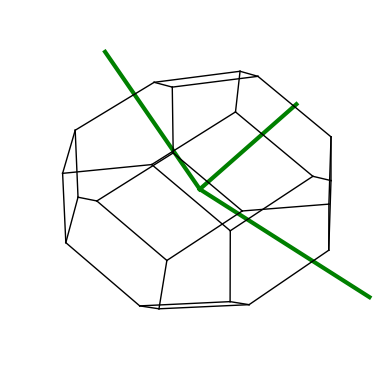

In [5]:
from pymatgen.electronic_structure.plotter import plot_brillouin_zone

plot_brillouin_zone(lattice.reciprocal_lattice)

## 6. Diffractogramme (Cu Kα, λ=1.54060 Å)

In [ ]:
from pymatgen.analysis.diffraction.xrd import XRDCalculator

wavelength = 1.54060
xrd = XRDCalculator(wavelength=wavelength)
pattern = xrd.get_pattern(structure)

#Il faut pas oublier le graphs avec les trois pics ;) 
pattern

DiffractionPattern
$2\Theta$: [24.93668248 29.97559841 31.07029778 33.59645178 37.42575522 46.41022204
 46.4102359  48.6711546  50.80235573 51.16372679 55.06230619 57.39993312
 57.3999434  57.84920675 57.84921966 60.32646944 62.29281469 62.29283115
 63.58831912 64.77722252 70.62059682 70.95619563 70.95620672 73.87264017
 73.87265635 74.98365228 74.98366644 78.18906077 78.18908265 79.14308675
 79.14310136 79.83019358 80.73688891 80.73690146 82.51693099 82.51694201
 82.70056554 82.70057705 82.76359117 82.76360227 83.07733026 87.54674035
 89.45444009 89.45445111]
Intensity: [7.31223152e+01 1.00000000e+02 4.15333972e+00 8.93469134e+00
 3.92693826e+00 4.22593358e+01 1.40864353e+01 2.32573306e-02
 1.61720309e+01 5.27073402e+00 6.03417842e+00 4.85010488e+00
 1.61670081e+00 2.91217875e+00 2.91217609e+00 4.30758719e+00
 3.68674141e-01 3.68673661e-01 1.06978099e+01 1.69686151e+00
 4.83885914e+00 1.39543052e-01 1.39542974e-01 7.02488290e-02
 2.34162700e-02 1.52708324e+00 1.52708221e+00 1.74491301

## 7. Structure de bandes électroniques

In [1]:
# Télécharger la structure de bandes
from mp_api.client import MPRester
from pymatgen.io.cif import CifWriter
from matplotlib import pyplot as plt 
from tabulate import tabulate
from pymatgen.electronic_structure import bandstructure
from pymatgen.electronic_structure import plotter
import numpy as np

m = MPRester("PXBFSqNjWuCbMDn152B5RsMt61dfXOLI")
bandstructure = m.get_bandstructure_by_material_id("mp-1378")

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
#initialisation des données et variables utiles par la suite
plot = plotter.BSPlotter(bandstructure)
# crée un dictionnaire qui contient ce que je veux
data = plot.bs_plot_data()
zero_energy = data.get('zero_energy')
distance = data.get('ticks').get('distance')
labels = data.get('ticks').get('label')
distances = data.get('distances')
energy = data.get('energy')
bandgap = bandstructure.get_band_gap()
vbmData = bandstructure.get_vbm()
cbmData = bandstructure.get_cbm()

Type de energy['1'][0]: <class 'numpy.ndarray'>
Longueur de energy['1'][0]: 20

Type de energy['1'][0][0]: <class 'numpy.ndarray'>
Longueur de energy['1'][0][0]: 27


Text(0.5, 1.0, 'Structure de bandes électroniques du LiC')

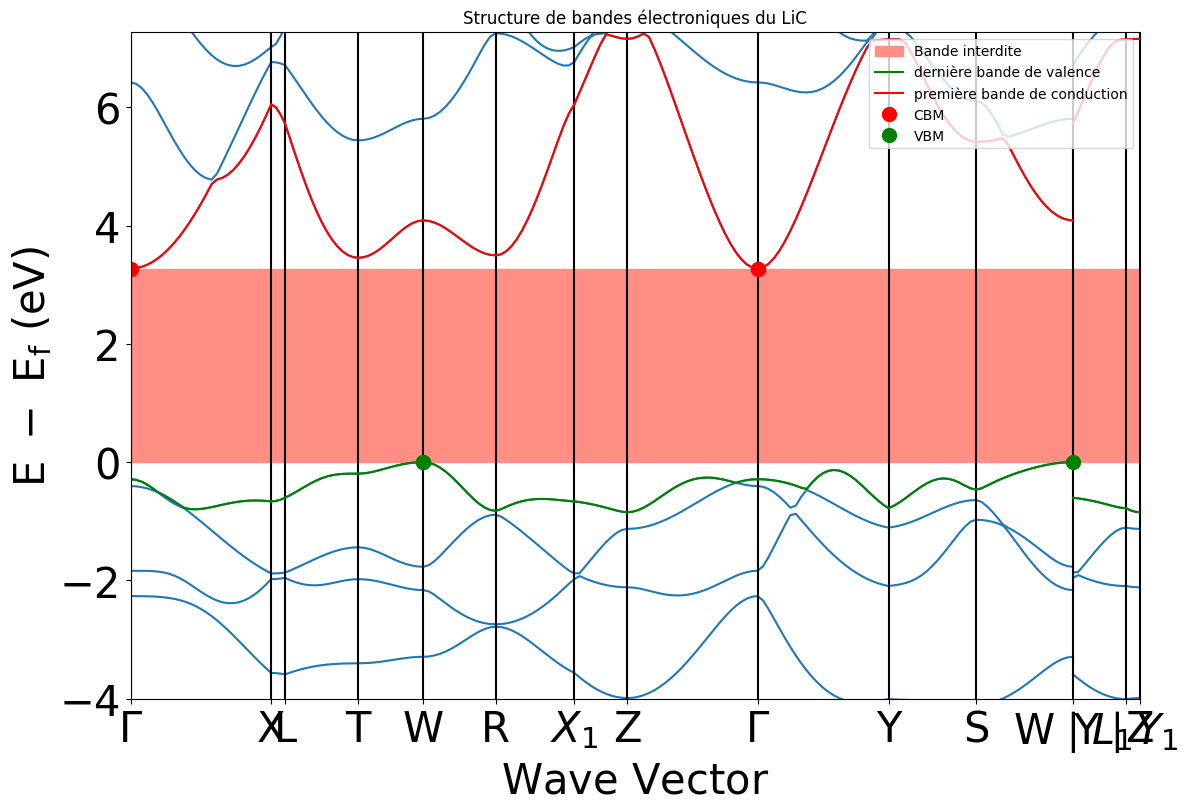

In [5]:
#plot de la structure de bandes

# on remarque que les énergies sont données par rapport à l'énergie de Fermi, d'où le zéro à 0 eV.
# Cela explique aussi pourquoi CBM et VBM sont à des valeurs différentes de sur le graphe , 
# alors qu'elles sont à des énergies positives et négatives respectivement par rapport à l'énergie de Fermi.
# energy est donc : {'1': [segment0, segment1, ..., segment12]}
# Chaque segment est lui-même une liste ou un array

print("Type de energy['1'][0]:", type(energy['1'][0]))
print("Longueur de energy['1'][0]:", len(energy['1'][0]))
print()
print("Type de energy['1'][0][0]:", type(energy['1'][0][0]))
print("Longueur de energy['1'][0][0]:", len(energy['1'][0][0]))
vbm_idx = list(vbmData.get('band_index').values())[0][0]
cbm_idx = list(cbmData.get('band_index').values())[0][0]

plot.get_plot()
plt.fill_between(np.linspace(distance[0],distance[-1],500),
                 0, bandgap.get('energy'), color="#FF8E85", label = "Bande interdite")
#plot la derniere bande de valence en vert et la premiere bande de conduction en rouge
for i in range(len(distances)):
    plt.plot(distances[i], energy['1'][i][vbm_idx], 'g', label = "dernière bande de valence" if i == 0 else "")
    plt.plot(distances[i], energy['1'][i][cbm_idx], 'r', label = "première bande de conduction" if i == 0 else "")
#plot les points du VBM en vert et du CBM en rouge
cbms = data.get('cbm')
for i in range(len(cbms)):
    (a, b) = cbms[i]
    plt.plot(a, b, 'or', markersize=10, label = "CBM" if i == 0 else "")

vbms = data.get('vbm')
for i in range(len(vbms)):
    (a, b) = vbms[i]
    plt.plot(a, b, 'og', markersize=10, label = "VBM" if i == 0 else "")
#legende
plt.legend(loc = "upper right")
plt.title("Structure de bandes électroniques du LiC")

## 8. Analyse de la structure de bandes: dispersions

In [6]:
#calcule la pente sur l'intervalle (x,y)
#renvoit un tableau pour un affichage pratique des flèches : 
#    pour chaque intervalle entre 2 kpoints : [pente,x_0,y_0,dx,dy]
def slope(x,y):
	return np.array([abs((y[-1]-y[0])/(x[-1]-x[0])),x[0],y[0],x[-1]-x[0],y[-1]-y[0]])

#calcule la dispersions maximale et minimale de la bande y
#retourne : s=tableau des résultats retournés par slope pour chaque intervalle de kpoints
#           l'indice de la pente maximale dans s
#           l'indice de la pente minimale dans s
def computeDispersions_filtered(y, emin=-1.0, emax=1.0):
    """
    Calcule les dispersions uniquement sur les segments
    où la bande reste dans la fenêtre [emin, emax] eV
    """
    slopes = []
    indices = []
    for i in range(len(distances)):
        e = energy['1'][i][y]
        # On garde le segment seulement si toute la bande
        # reste dans la fenêtre d'énergie
        if np.min(e) >= emin and np.max(e) <= emax:
            slopes.append(slope(distances[i], e))
            indices.append(i)
    
    if not slopes:
        print("Aucun segment trouvé dans la fenêtre d'énergie !")
        return None, None, None
    
    slopes = np.array(slopes).T
    # print(f"Segments retenus : {indices}")
    # for k, idx in enumerate(indices):
    #     print(f"  Segment {idx} ({labels[idx]}→{labels[idx+1]}) : pente = {slopes[0,k]:.4f} eV/Å")
    
    return (slopes, indices[np.argmax(slopes[0])], indices[np.argmin(slopes[0])])

(vbs, maxVb, minVb) = computeDispersions_filtered(vbm_idx, emin=-1.0, emax=0.1)
(cbs, maxCb, minCb) = computeDispersions_filtered(cbm_idx, emin=3.0,  emax=7.0)



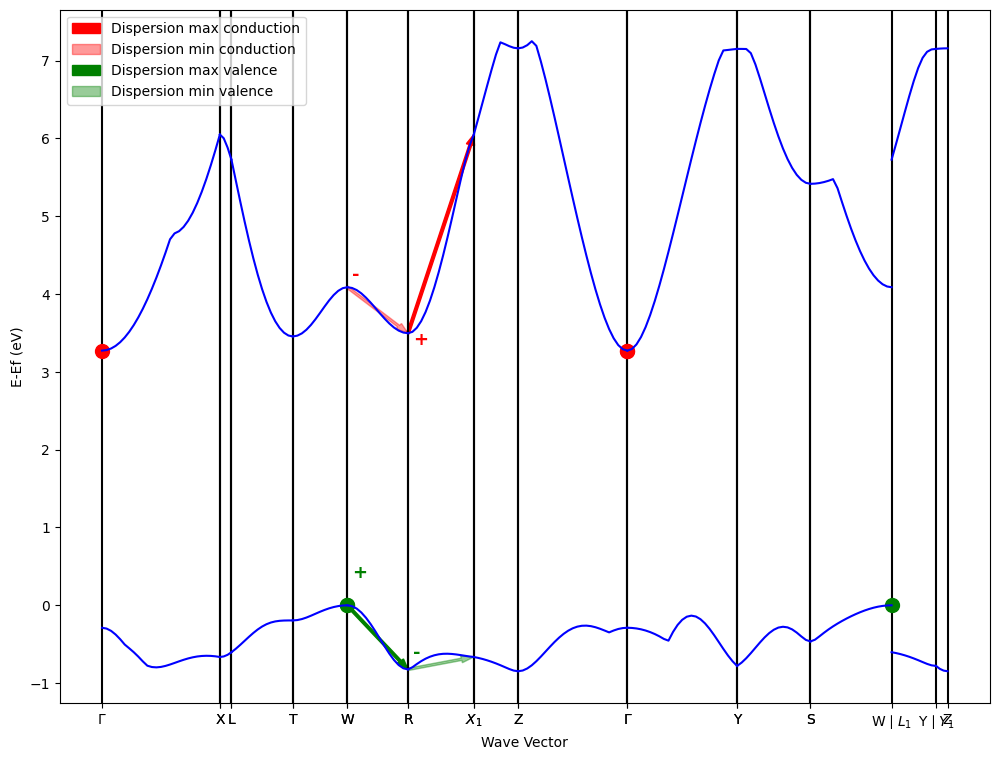

In [7]:
# affichage des endroits de dispersion maximale et minimale pour les bandes de valence et de conduction



# print("=== Bande de conduction : min/max par segment ===")
# for i in range(len(distances)):
#     e = energy['1'][i][cbm_idx]
#     print(f"  Segment {i} ({labels[i]}→{labels[i+1]}) : "
#           f"min={np.min(e):.3f} eV, max={np.max(e):.3f} eV, "
#           f"pente={abs(e[-1]-e[0])/(distances[i][-1]-distances[i][0]):.3f} eV/Å")
vbm_points = data.get('vbm')
cbm_points = data.get('cbm')
fig,ax = plt.subplots(1,1,figsize=(12,9))
for i in range(len(distance)):
    plt.axvline(distance[i],0,color="black")
    
for i in range(len(vbm_points)):
    (a,b) = vbm_points[i]
    plt.plot(a,b,'og',markersize=10)
for i in range(len(cbm_points)):
    (a,b) = cbm_points[i]
    plt.plot(a,b,'or',markersize=10)
    
for i in range(len(distances)):
    plt.plot(distances[i],energy['1'][i][vbm_idx],'b')
    plt.plot(distances[i],energy['1'][i][cbm_idx],'b')

ax.set_xticks(distance)
ax.set_xticklabels(labels)
ax.set_xlabel('Wave Vector')
ax.set_ylabel('E-Ef (eV)')

# maxVb, minVb, maxCb, minCb sont maintenant des indices de segments
# On recalcule les données de la flèche directement depuis le segment
def get_arrow(seg_idx, band_idx):
    x0 = distances[seg_idx][0]
    y0 = energy['1'][seg_idx][band_idx][0]
    dx = distances[seg_idx][-1] - x0
    dy = energy['1'][seg_idx][band_idx][-1] - y0
    return x0, y0, dx, dy

x0,y0,dx,dy = get_arrow(maxCb, cbm_idx)
plt.arrow(x0,y0,dx,dy,color='red',width=0.03,length_includes_head=True, label= "Dispersion max conduction")
x0,y0,dx,dy = get_arrow(minCb, cbm_idx)
plt.arrow(x0,y0,dx,dy,color=('red', 0.4),width=0.03,length_includes_head=True, label= "Dispersion min conduction")
x0,y0,dx,dy = get_arrow(maxVb, vbm_idx)
plt.arrow(x0,y0,dx,dy,color='green',width=0.03,length_includes_head=True, label= "Dispersion max valence")
x0,y0,dx,dy = get_arrow(minVb, vbm_idx)
plt.arrow(x0,y0,dx,dy,color=('green', 0.4),width=0.03,length_includes_head=True, label= "Dispersion min valence")

plt.text(distances[maxCb][0]+0.05, energy['1'][maxCb][cbm_idx][0]-0.15, "+", fontsize=13, fontweight='bold', color='red')
plt.text(distances[minCb][0]+0.05, energy['1'][minCb][cbm_idx][0]+0.1,  "-", fontsize=13, fontweight='bold', color='red')
plt.text(distances[maxVb][0]+0.05, energy['1'][maxVb][vbm_idx][0]+0.35, "+", fontsize=13, fontweight='bold', color='green')
plt.text(distances[minVb][0]+0.05, energy['1'][minVb][vbm_idx][0]+0.15, "-", fontsize=13, fontweight='bold', color='green')

plt.legend(loc = "upper left")
plt.show()

## 9. Masse effective (approximation parabolique)


--------------------------  -------------------------------------------------------------------
Parabole d'approximation :  y(k) = -1.0014724594103093k² + 4.92419792587298k -6.027192048189632
Dérivée seconde :           -2.0029449188206185 eVÅ²
Masse effective :           -3.465555893569862e-30 kg




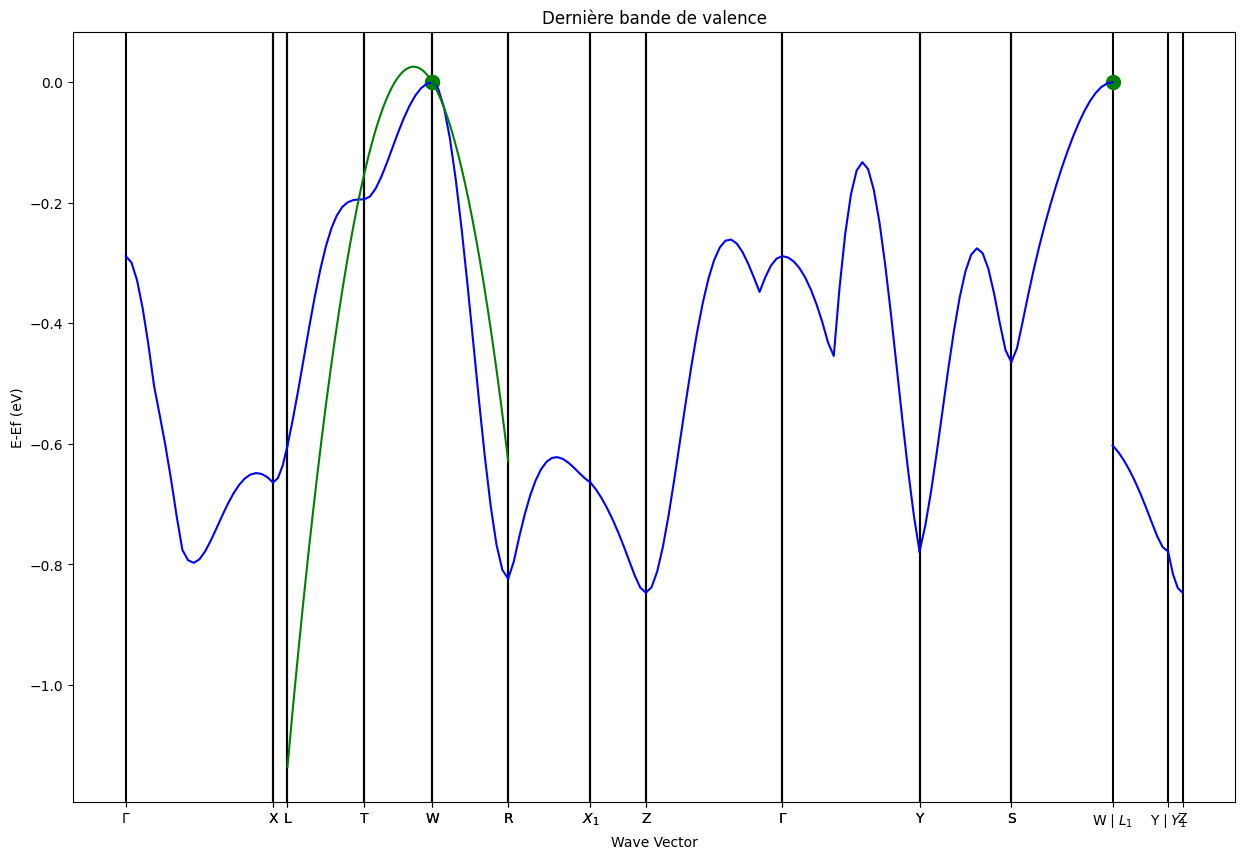

In [8]:
# constantes importantes
hbar2 = ((6.62607004*10**(-34))/(2*np.pi))**2
electronvolt = 1.602176634*10**(-19)
angstrom = 10**(-10)

#plot de la dernière bande de valence et des VBM 
fig,ax = plt.subplots(1,1,figsize=[15,10])
for i in range(len(distance)):
    plt.axvline(distance[i],0,color="black")
for i in range(len(vbm_points)):
    (a,b) = vbm_points[i]
    plt.plot(a,b,'og',markersize=10)
for i in range(len(distances)):
    plt.plot(distances[i],energy['1'][i][vbm_idx],'b')
ax.set_xticks(distance)
ax.set_xticklabels(labels)
ax.set_xlabel('Wave Vector')
ax.set_ylabel('E-Ef (eV)')
plt.title('Dernière bande de valence')

#calcul de la parabole d'approximation aux alentours du VBM
# On cherche le segment contenant le VBM
vbm_k = vbm_points[0][0]  # position k du VBM
vbm_seg = 0
for i in range(len(distances)):
    if distances[i][0] <= vbm_k <= distances[i][-1]:
        vbm_seg = i
        break

seg_prev = max(0, vbm_seg - 1)
seg_next = min(len(distances)-1, vbm_seg + 1)

ks = np.zeros(3)
es = np.zeros(3)
(ks[1],es[1]) = vbm_points[0]
(ks[0],es[0]) = (distances[seg_prev][-2], energy['1'][seg_prev][vbm_idx][-2])
(ks[2],es[2]) = (distances[seg_next][2],  energy['1'][seg_next][vbm_idx][2])
a = np.polyfit(ks,es,2)

#affichage des résultats
# calcul: E(k) approximée par la parabole, E(k) = a[0]k^2 + a[1]k + a[2] donc E''(k) = 2*a[0]
# Masse effective: m* = ħ² / (d²E/dk²) = ħ² / (2*a[0]) (en eV·Å², à convertir en kg)
print(tabulate([["Parabole d'approximation : ","y(k) = "+str(a[0])+"k\u00b2 + "+str(a[1])+"k "+str(a[2])],
                ["Dérivée seconde : ",str(2*a[0])+" eV\u212b\u00b2"],
                ["Masse effective : ",str(hbar2/(2*a[0]*electronvolt*(angstrom)**2))+" kg"]],
                headers=["",""]))
print("\n")
x = np.linspace(distances[seg_prev][0],distances[seg_next][-1],1000)
plt.plot(x,np.polyval(a,x),'g')
plt.show()


--------------------------  ------------------------------------------------------------------
Parabole d'approximation :  y(k) = 7.931331435324315k² -88.92807181875622k +252.54360452229767
Dérivée seconde :           15.86266287064863 eVÅ²
Masse effective :           4.375884190767505e-31 kg




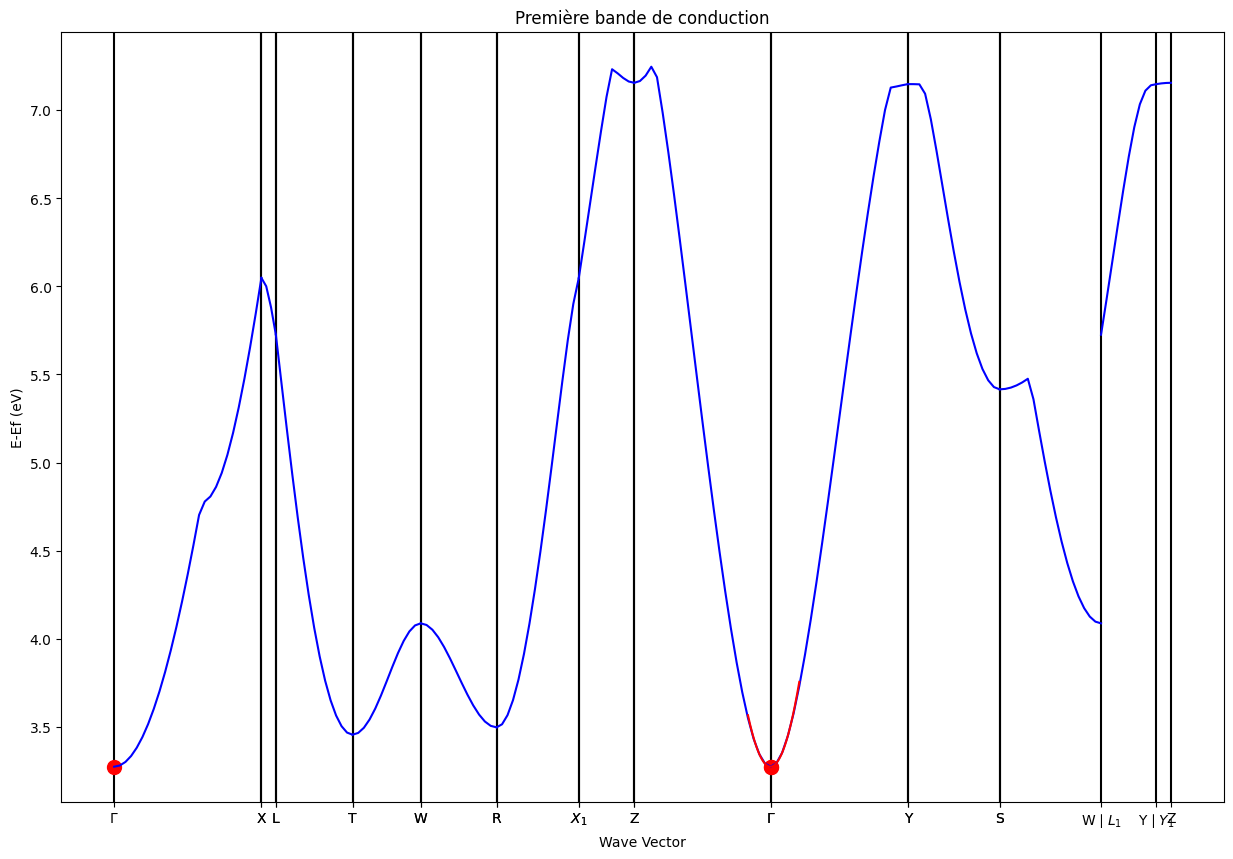

In [9]:
# print("Tous les points CBM:")
# for i, pt in enumerate(cbm_points):
#     print(f"  cbm_points[{i}]: k={pt[0]:.4f}, E={pt[1]:.4f} eV")

#plot de la première bande de conduction et du CBM
fig,ax = plt.subplots(1,1,figsize=[15,10])
for i in range(len(distance)):
    plt.axvline(distance[i],0,color="black")
for i in range(len(cbm_points)):
    (a,b) = cbm_points[i]
    plt.plot(a,b,'or',markersize=10)
for i in range(len(distances)):
    plt.plot(distances[i],energy['1'][i][cbm_idx],'b')
ax.set_xticks(distance)
ax.set_xticklabels(labels)
ax.set_xlabel('Wave Vector')
ax.set_ylabel('E-Ef (eV)')
plt.title('Première bande de conduction')

# CBM en Γ central (k=5.6084), à la jonction des segments 7 et 8
# On prend un point dans le segment 7 (avant Γ) et un dans le segment 8 (après Γ)
ks2 = np.zeros(3)
es2 = np.zeros(3)
(ks2[1], es2[1]) = cbm_points[1]                                        # CBM en Γ
(ks2[0], es2[0]) = (distances[7][-3], energy['1'][7][cbm_idx][-3])      # point avant Γ
(ks2[2], es2[2]) = (distances[8][2],  energy['1'][8][cbm_idx][2])       # point après Γ
a2 = np.polyfit(ks2, es2, 2)

#affichage des résultats
# même calcul que pour la bande de valence, mais pour la conduction
print(tabulate([["Parabole d'approximation : ","y(k) = "+str(a2[0])+"k\u00b2 "+str(a2[1])+"k +"+str(a2[2])],
                ["Dérivée seconde : ",str(2*a2[0])+" eV\u212b\u00b2"],
                ["Masse effective : ",str(hbar2/(2*a2[0]*electronvolt*(angstrom)**2))+" kg"]],
               headers=["",""]))
print("\n")
x2 = np.linspace(distances[7][-5], distances[8][5], 1000)
plt.plot(x2, np.polyval(a2,x2), 'r')
plt.show()

## 10. Structure de bandes de phonons

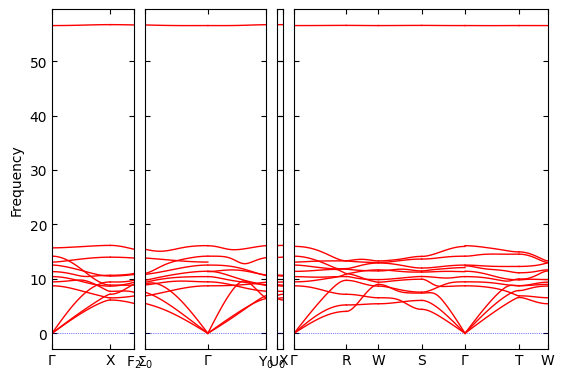

In [17]:
from phonopy import load as phonopy_load
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections
import matplotlib.pyplot as plt

# Charger le fichier (phonopy lit le .xz directement)
phonon = phonopy_load("phonopy_params (2).yaml.xz")

# Tracer automatiquement la structure de bandes
phonon.auto_band_structure(
    plot=True,
    write_yaml=False
)
plt.show()

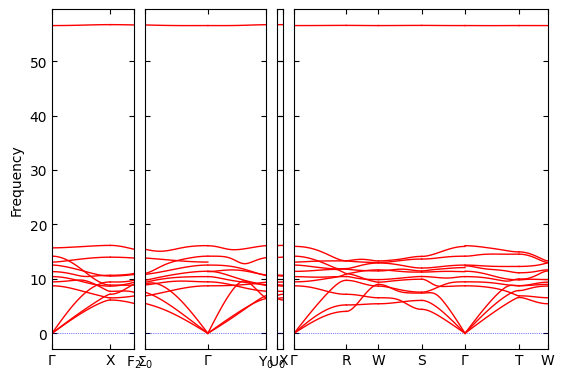

In [18]:
from phonopy import load as phonopy_load
import matplotlib.pyplot as plt

phonon = phonopy_load("phonopy_params (2).yaml.xz")
phonon.auto_band_structure(npoints=101)

# Correction : plot_band_structure() retourne juste un objet plt
plt_obj = phonon.plot_band_structure()

# Récupérer fig et ax depuis matplotlib directement
fig = plt.gcf()
ax = plt.gca()

# Personnalisation
ax.set_ylabel("Frequencies (THz)", fontsize=13)
ax.set_xlabel("Wave Vector", fontsize=13)
ax.set_title("Phonon Band Structure - LiC (mp-1378)", fontsize=14)
ax.set_ylim(0,15)
ax.axhline(y=0, color='k', linewidth=0.8, linestyle='--')

plt.show()

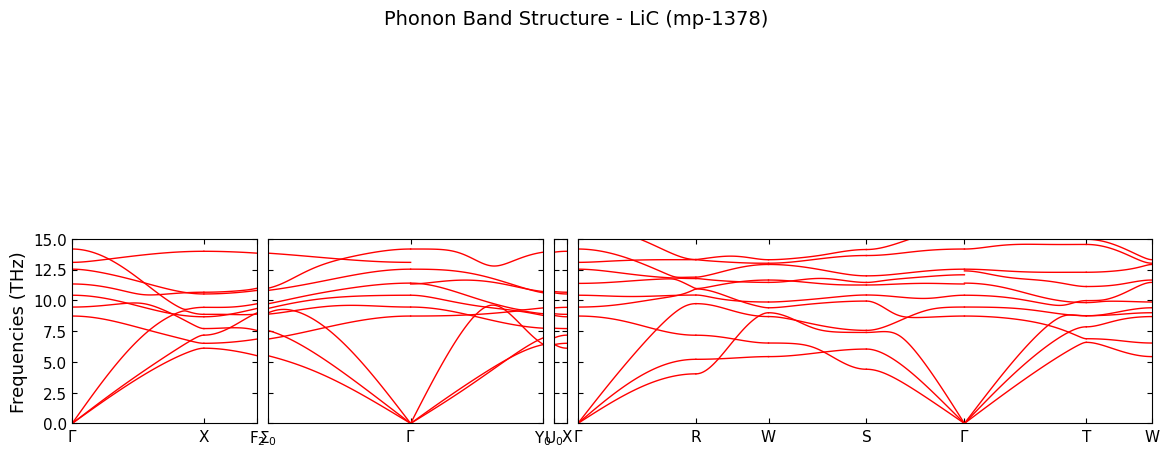

In [19]:
from phonopy import load as phonopy_load
import matplotlib.pyplot as plt

phonon = phonopy_load("phonopy_params (2).yaml.xz")
phonon.auto_band_structure(npoints=101)
phonon.plot_band_structure()

fig = plt.gcf()

# Agrandir la figure
fig.set_size_inches(12, 7)

# Ajuster tous les axes
for ax in fig.get_axes():
    ax.set_ylim(0, 15)
    ax.set_ylabel("Frequencies (THz)", fontsize=13)
    ax.tick_params(axis='both', labelsize=11)

# Supprimer les marges et maximiser l'espace
plt.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.12, wspace=0.05)
fig.suptitle("Phonon Band Structure - LiC (mp-1378)", fontsize=14)

plt.savefig("phonon_LiC.png", dpi=150, bbox_inches='tight')
plt.show()

## 11. Vitesse du son (branches acoustiques)

In [20]:
phonon = phonopy_load("phonopy_params (2).yaml.xz")
phonon.auto_band_structure(npoints=101)

# Récupérer les données brutes
bs = phonon.band_structure

# Équivalences :
distances  = bs.distances    # équivalent data['distances']
frequency  = bs.frequencies  # équivalent data['frequency']

# Labels des points de haute symétrie
labels = bs.labels
connections = bs.path_connections


In [21]:
import numpy as np

def find_acoustic_branches(frequencies, threshold=0.5):
    frequence = []
    branche = []
    zone = []
    
    for i in range(len(frequencies)):  # boucle sur les segments
        n_branches = frequencies[i].shape[1]  # phonopy: (n_qpoints, n_branches)
        
        for j in range(n_branches):  # boucle sur les branches
            # Extraire la branche j du segment i : tous les qpoints
            freq_branch = frequencies[i][:, j]  # ← correction clé : [:, j] au lieu de [j]
            
            # Condition : fréquence quasi-nulle au début OU à la fin du segment
            if (abs(freq_branch[0]) < threshold or abs(freq_branch[-1]) < threshold) \
                and j not in branche and i not in zone:
                zone.append(i)
                branche.append(j)
                frequence.append(freq_branch)
    
    return frequence, branche, zone

acoustic_branches = find_acoustic_branches(frequency)
frequences_acoustiques, indices_branches, indices_zones = acoustic_branches

print("Branches acoustiques :", indices_branches)
print("Zones correspondantes :", indices_zones)

# Récupérer distances et fréquences pour chaque branche acoustique
q1 = distances[indices_zones[0]]
q2 = distances[indices_zones[1]]
q3 = distances[indices_zones[2]]

f1 = frequency[indices_zones[0]][:, indices_branches[0]]
f2 = frequency[indices_zones[1]][:, indices_branches[1]]
f3 = frequency[indices_zones[2]][:, indices_branches[2]]

Branches acoustiques : [0, 1, 2]
Zones correspondantes : [0, 2, 3]


In [22]:
import numpy as np

def get_segment_names(labels, path_connections):
    segment_names = []
    label_idx = 0
    
    for i, connected in enumerate(path_connections):
        start = labels[label_idx]
        end   = labels[label_idx + 1]
        segment_names.append(f"{start}-{end}")
        
        if connected:
            label_idx += 1
        else:
            label_idx += 2
    
    return segment_names

def find_acoustic_branches(frequencies, distances, segment_names, threshold=0.5):
    frequence = []
    branche   = []
    zone      = []
    noms      = []

    for i in range(len(frequencies)):
        n_branches = frequencies[i].shape[1]

        for j in range(n_branches):
            freq_branch = frequencies[i][:, j]

            if (abs(freq_branch[0]) < threshold or abs(freq_branch[-1]) < threshold) \
                and j not in branche and i not in zone:
                zone.append(i)
                branche.append(j)
                frequence.append(freq_branch)
                noms.append(segment_names[i])

    return frequence, branche, zone, noms

segment_names = get_segment_names(labels, connections)

frequences_acoustiques, indices_branches, indices_zones, noms_segments = \
    find_acoustic_branches(frequency, distances, segment_names)

print("Branches acoustiques :", indices_branches)
print("Zones correspondantes :", indices_zones)
print("Ceci correspond aux bandes", ", ".join(noms_segments))


Branches acoustiques : [0, 1, 2]
Zones correspondantes : [0, 2, 3]
Ceci correspond aux bandes $\Gamma$-$\mathrm{X}$, $\Sigma_0$-$\Gamma$, $\Gamma$-$\mathrm{Y_0}$


## 12. Densité d'états de phonons

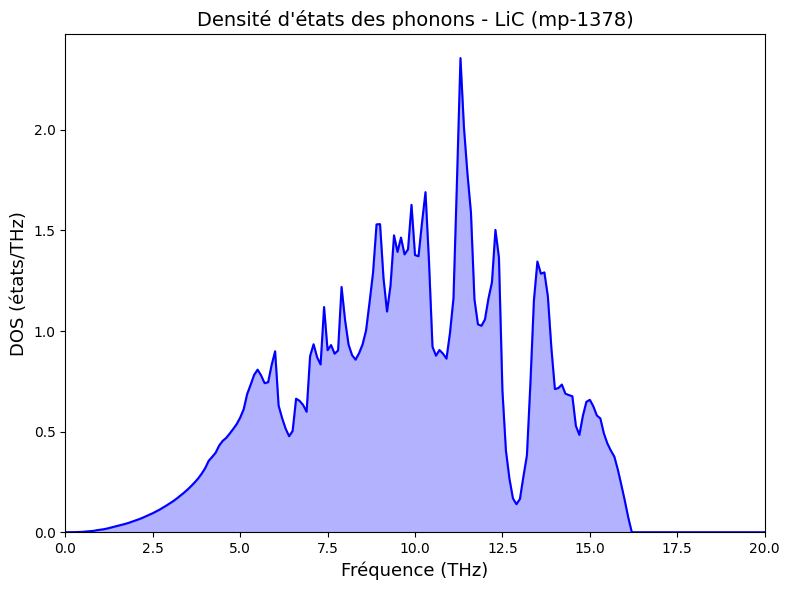

In [23]:


phonon = phonopy_load("phonopy_params (2).yaml.xz")

# Méthode tétraèdre — plus stable que la méthode gaussienne
phonon.run_mesh(
    [20, 20, 20],
    is_mesh_symmetry=False,
    with_eigenvectors=False,
    is_gamma_center=True
)

phonon.run_total_dos(
    use_tetrahedron_method=True,   # ← remplace sigma
    freq_min=0.0,
    freq_max=20.0,
    freq_pitch=0.1
)

# Récupérer les données
dos_dict        = phonon.get_total_dos_dict()
frequencies_dos = dos_dict["frequency_points"]
dos             = dos_dict["total_dos"]

# Tracer
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(frequencies_dos, dos, color='blue', linewidth=1.5)
ax.fill_between(frequencies_dos, dos, alpha=0.3, color='blue')
ax.set_xlabel("Fréquence (THz)", fontsize=13)
ax.set_ylabel("DOS (états/THz)", fontsize=13)
ax.set_title("Densité d'états des phonons - LiC (mp-1378)", fontsize=14)
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 13. Modèles de Debye et d'Einstein

### Chaleur spécifique molaire normalisée à volume constant

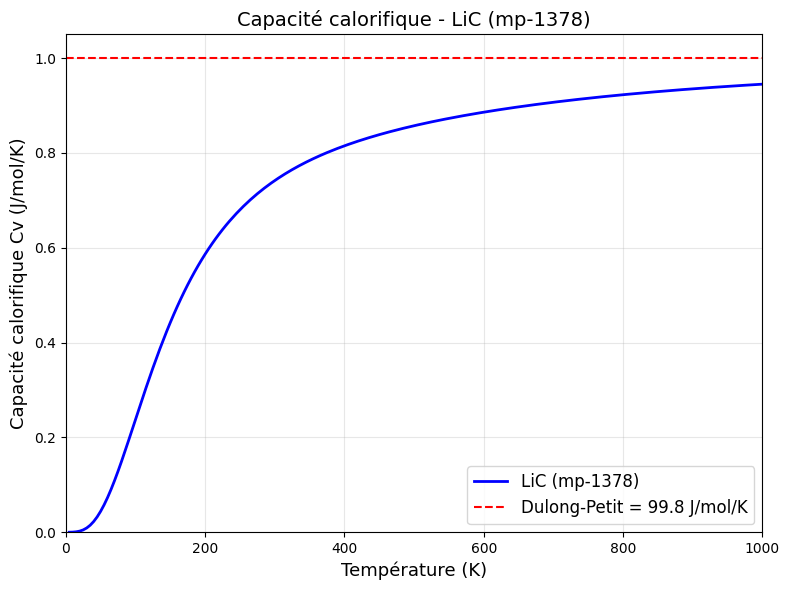

In [ ]:
phonon.run_mesh(
    [20, 20, 20],
    is_mesh_symmetry=False,
    with_eigenvectors=False,
    is_gamma_center=True
)
phonon.run_thermal_properties(5, 1000, 5)
thermal_dict = phonon.get_thermal_properties_dict()
temperatures = thermal_dict["temperatures"] 
heat_capacity = thermal_dict["heat_capacity"]

N_atoms = len(phonon.primitive)  # nombre d'atomes dans la maille primitive
R = 8.314  # J/mol/K
# Limite Dulong-Petit
dulong_petit = 3 * N_atoms * R  # J/mol/K

heat_capacity_normalized = heat_capacity / dulong_petit

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(temperatures, heat_capacity_normalized, color='blue', linewidth=2, label='LiC (mp-1378)')

ax.axhline(y=1, color='red', linestyle='--', 
           linewidth=1.5, label=f'Dulong-Petit = {dulong_petit:.1f} J/mol/K')

ax.set_xlabel("Température (K)", fontsize=13)
ax.set_ylabel("Capacité calorifique Cv normalisée (J/mol/K)", fontsize=13)
ax.set_title("Capacité calorifique normalisée à volume constant - LiC (mp-1378)", fontsize=14)
ax.set_xlim(0, 1000)
ax.set_ylim(bottom=0)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



#### Modèle d'Einstein 

C:\Users\yousr\AppData\Local\Temp\ipykernel_15608\237833565.py:20: RuntimeWarning: overflow encountered in scalar power
  return (x**2 * exp_x) / (denom**2)


Température d'Einstein optimale : 534.8 K


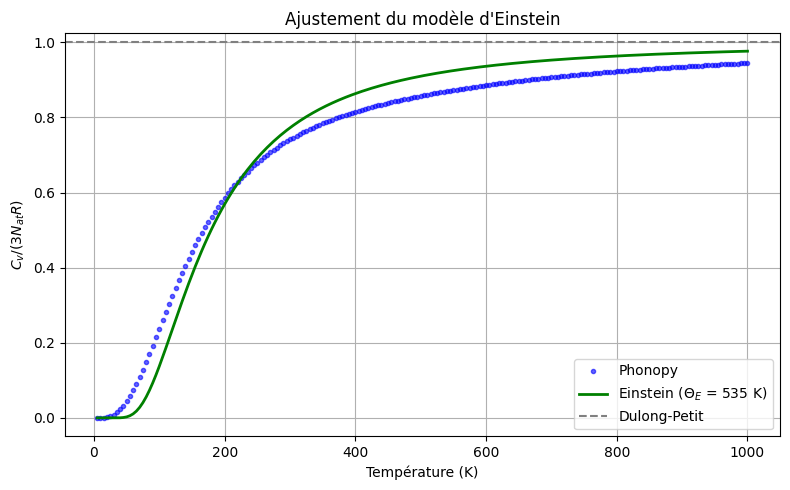

In [28]:
# Ajustement moindres carrés pour ΘD et ΘE
# Implémentation à compléter

import numpy as np
import matplotlib.pyplot as plt

norm = 3 * N_atoms * 8.314  # 3 * N_atomes * R pour LiC

# Normaliser heat_capacity
heat_capacity_norm = [c / norm for c in heat_capacity]

def cv_einstein(theta_E, T):
    if T == 0:
        return 0
    x = theta_E / T
    exp_x = np.exp(x)
    if np.isinf(exp_x):   # remplace try/except
        return 0
    denom = np.expm1(x)
    return (x**2 * exp_x) / (denom**2)

def erreur_einstein(theta):
    erreur_totale = 0
    for T, c_exp in zip(temperatures, heat_capacity_norm):  # ← normalisé
        if T == 0:
            continue
        cv_th = cv_einstein(theta, T)
        erreur_totale += (cv_th - c_exp)**2
    return erreur_totale

# Recherche plus fine
theta_E_opt = min(np.linspace(1, 2000, 10000), key=erreur_einstein)
print(f"Température d'Einstein optimale : {theta_E_opt:.1f} K")

cv_einstein_curve = [cv_einstein(theta_E_opt, T) for T in temperatures]

plt.figure(figsize=(8, 5))
plt.plot(temperatures, heat_capacity_norm, 'bo', markersize=3,
         label='Phonopy', alpha=0.6)
plt.plot(temperatures, cv_einstein_curve, 'g-', linewidth=2,
         label=fr"Einstein ($\Theta_E$ = {theta_E_opt:.0f} K)")
plt.axhline(1.0, linestyle='--', color='gray', label="Dulong-Petit")
plt.xlabel("Température (K)")
plt.ylabel(r"$C_v / (3N_{at}R)$")
plt.title("Ajustement du modèle d'Einstein")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Modèle de Deybes

Température de Debye optimale : 728 K


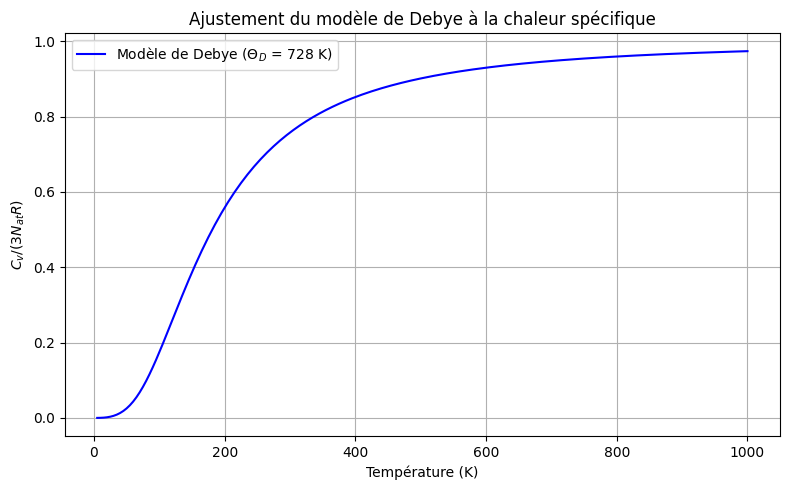

In [30]:
from scipy.integrate import quad
def integrand_debye(x):
    return (x**4 * np.exp(x)) / ((np.exp(x) - 1)**2)

def cv_debye(theta_D, T):
    if T == 0:
        return 0
    integral, _ = quad(integrand_debye, 0, theta_D / T)
    return 3 * (T / theta_D)**3 * integral  # normalisé

def erreur_debye(theta):
    erreur_totale = 0

    for i in range(len(temperatures)):
        T = temperatures[i]
        c_exp = heat_capacity_norm[i]

        c_th = cv_debye(theta, T)     
        ecart = c_th - c_exp        
        erreur_totale += ecart**2     

    return erreur_totale

theta_D_opt = min(range(1, 1000), key=erreur_debye)
print("Température de Debye optimale :", theta_D_opt, "K")
cv_debye_curve = [cv_debye(theta_D_opt, T) for T in temperatures]

plt.figure(figsize=(8, 5))
plt.plot(temperatures, cv_debye_curve, label=fr"Modèle de Debye ($\Theta_D$ = {theta_D_opt} K)", color='blue')
plt.xlabel("Température (K)")
plt.ylabel(r"$C_v / (3N_{at}R)$")
plt.title("Ajustement du modèle de Debye à la chaleur spécifique")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 14. Courbes de chaleur spécifique

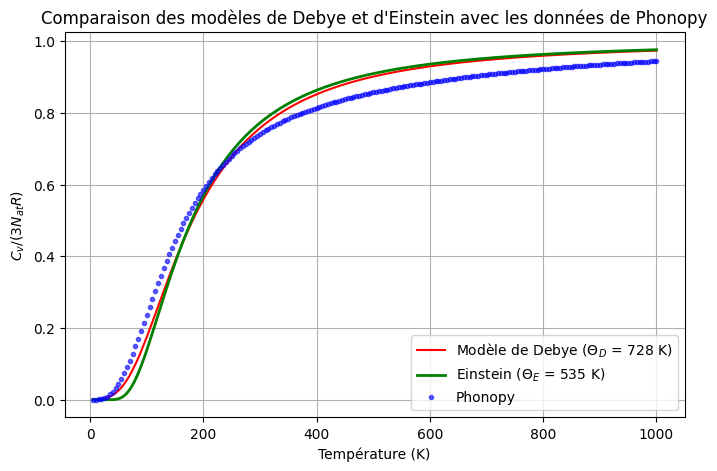

In [32]:


# Tracer les trois courbes ici

plt.figure(figsize=(8, 5))
plt.plot(temperatures, cv_debye_curve, label=fr"Modèle de Debye ($\Theta_D$ = {theta_D_opt} K)", color='red')
plt.plot(temperatures, cv_einstein_curve, 'g-', linewidth=2,
         label=fr"Einstein ($\Theta_E$ = {theta_E_opt:.0f} K)")
plt.plot(temperatures, heat_capacity_norm, 'bo', markersize=3,
         label='Phonopy', alpha=0.6)
plt.xlabel("Température (K)")
plt.ylabel(r"$C_v / (3N_{at}R)$")
plt.legend()
plt.title("Comparaison des modèles de Debye et d'Einstein avec les données de Phonopy")
plt.grid(True)
plt.show()

##### Comparaison des trois densités d'états 


La fréquence de Debye vaut :  11.138617528617605  [THz]
La fréquence d'Einstein vaut :  15.162902206835476 [THz]
-------------------------------------------------------------------------------------------------------------------


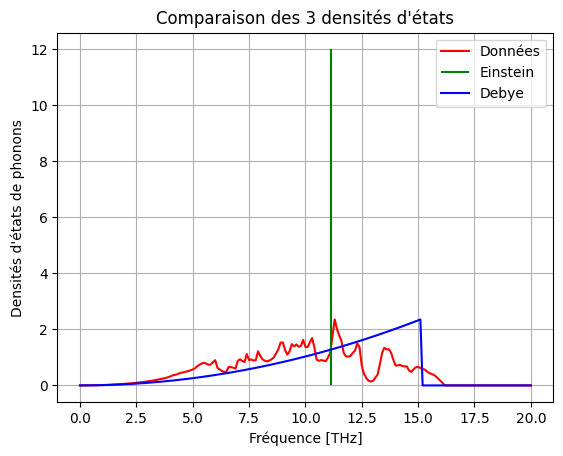

In [33]:
k_B = 1.380649e-23
conv_THz = 1e-12
h_barre = 1.055e-34

freq = frequencies_dos
dens = dos

omega_e = conv_THz*k_B*theta_E_opt/h_barre
f_e = omega_e/(2*np.pi)

omega_d = conv_THz*k_B*theta_D_opt /h_barre
f_d = omega_d / (2 * np.pi)

print("\nLa fréquence de Debye vaut : ",f_e," [THz]")
print("La fréquence d'Einstein vaut : ",f_d,"[THz]")
print("-------------------------------------------------------------------------------------------------------------------")

dens_d = np.zeros(len(freq))
for i,f in enumerate(freq):
    omega = 2*np.pi*f
    if omega < omega_d:
        dens_d[i] = (9*N_atoms*(omega)**2/(omega_d**3))

plt.plot(freq, dens,color="red", label="Données")
plt.vlines(f_e, 0, 3 * N_atoms ,color="green", label = "Einstein")
plt.plot(freq, dens_d*(2*np.pi), color='blue', label="Debye")
plt.title("Comparaison des 3 densités d'états")
plt.ylabel("Densités d'états de phonons")
plt.xlabel("Fréquence [THz]")
plt.legend()
plt.grid()
plt.show()